# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

THE ABOVE LINK IS JUST FOR REFERENCE - PLEASE DO NOT USE THE DATASET PROVIDED IN THE ABOVE WEBPAGE FOR SOLVING THE ASSIGNMENT.

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings
import warnings

# Suppress all warnings
warnings.filterwarnings('ignore')


In [2]:
# Import the libraries you will be using for analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [5]:
# Try loading one file
file_path = "/content/drive/MyDrive/EDA1/data/trip_records/2023-1.parquet"
df = pd.read_parquet(file_path)
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [6]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload
import os
print(os.getcwd())


/content


In [7]:
trip_records_path = os.path.join(os.getcwd(),"drive","MyDrive","EDA1", "data", "trip_records")
os.chdir(trip_records_path)

print(os.listdir())


['2023-9.parquet', '2023-5.parquet', '2023-6.parquet', '2023-2.parquet', '2023-1.parquet', '2023-8.parquet', '2023-7.parquet', '2023-10.parquet', '2023-3.parquet', '2023-12.parquet', '2023-4.parquet', '2023-11.parquet']


In [10]:
# Take a small percentage of entries from each hour of every date.
# Create a single dataframe for the year combining all the monthly data

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()

# Function to apply for sampling each group
def sample_group(group, frac, random_state):
    if len(group) > 0:
        return group.sample(frac=frac, random_state=random_state)
    return pd.DataFrame()

# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        df_month = pd.read_parquet(file_path)

        # Ensure datetime column is indeed datetime type
        df_month['tpep_pickup_datetime'] = pd.to_datetime(df_month['tpep_pickup_datetime'])

        # Group by date and hour, then apply sampling
        # Using observed=False to avoid performance warnings with categorical group keys in older pandas versions,
        # and to ensure all possible combinations are considered even if not present.
        sampled_data_month = df_month.groupby([df_month['tpep_pickup_datetime'].dt.date, df_month['tpep_pickup_datetime'].dt.hour], observed=False).apply(sample_group, frac=0.05, random_state=42)

        # Reset index to remove multi-index created by groupby
        if not sampled_data_month.empty:
            sampled_data_month = sampled_data_month.reset_index(drop=True)

        # Concatenate the sampled data of the current month to the main dataframe
        df = pd.concat([df, sampled_data_month])

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

# Reset index of the final DataFrame
df = df.reset_index(drop=True)

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [11]:
# Store the df in csv/parquet
# df.to_parquet('')
df.to_parquet('../Sampled_NYC_Taxi_Data.parquet')
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,2,2023-08-31 23:56:01,2023-09-01 00:18:41,1.0,3.11,1.0,N,114,246,1,21.20,1.0,0.5,0.00,0.00,1.0,26.20,2.5,0.00,NaN
1,2,2023-09-01 00:39:59,2023-09-01 01:00:28,NaN,4.71,NaN,None,113,238,0,24.83,0.0,0.5,4.32,0.00,1.0,33.15,NaN,NaN,NaN
2,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2.0,0.56,1.0,N,142,142,2,5.10,1.0,0.5,0.00,0.00,1.0,10.10,2.5,0.00,NaN
3,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,N,132,163,1,70.00,0.0,0.5,15.71,6.94,1.0,98.40,2.5,1.75,NaN
4,2,2023-09-01 00:42:13,2023-09-01 01:20:20,2.0,13.71,1.0,N,249,180,4,59.70,1.0,0.5,0.00,0.00,1.0,64.70,2.5,0.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896395,1,2023-11-30 23:01:23,2023-11-30 23:14:15,NaN,0.00,NaN,None,163,238,0,18.73,0.0,0.5,0.00,0.00,1.0,22.73,NaN,NaN,NaN
1896396,2,2023-11-30 23:21:56,2023-11-30 23:36:27,1.0,8.59,1.0,N,138,262,1,33.80,6.0,0.5,10.15,6.94,1.0,62.64,2.5,1.75,NaN
1896397,1,2023-11-30 23:59:24,2023-12-01 00:05:48,1.0,1.50,1.0,N,107,186,1,8.60,2.5,0.5,3.80,0.00,1.0,16.40,2.5,0.00,NaN
1896398,2,2023-11-30 23:25:14,2023-11-30 23:56:49,1.0,7.47,1.0,N,148,202,1,37.30,1.0,0.5,0.00,6.94,1.0,49.24,2.5,0.00,NaN


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [12]:
# Load the new data file
df_sampled = pd.read_parquet('../Sampled_NYC_Taxi_Data.parquet')


In [13]:
df_sampled.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,2,2023-08-31 23:56:01,2023-09-01 00:18:41,1.0,3.11,1.0,N,114,246,1,21.20,1.0,0.5,0.00,0.00,1.0,26.20,2.5,0.00,NaN
1,2,2023-09-01 00:39:59,2023-09-01 01:00:28,NaN,4.71,NaN,None,113,238,0,24.83,0.0,0.5,4.32,0.00,1.0,33.15,NaN,NaN,NaN
2,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2.0,0.56,1.0,N,142,142,2,5.10,1.0,0.5,0.00,0.00,1.0,10.10,2.5,0.00,NaN
3,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,N,132,163,1,70.00,0.0,0.5,15.71,6.94,1.0,98.40,2.5,1.75,NaN
4,2,2023-09-01 00:42:13,2023-09-01 01:20:20,2.0,13.71,1.0,N,249,180,4,59.70,1.0,0.5,0.00,0.00,1.0,64.70,2.5,0.00,NaN


In [14]:
df_sampled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [15]:
# Fix the index and drop any columns that are not needed
df_sampled.reset_index(drop=True, inplace=True)


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [16]:
# Combine the two airport fee columns
# Clean and merge both columns safely
df_sampled['Airport_fee'] = df_sampled['airport_fee'].fillna(0.0) + df_sampled['Airport_fee'].fillna(0.0)

# Drop the old lowercase column
df_sampled.drop(columns=['airport_fee'], inplace=True)

# Verify the results
print(df_sampled['Airport_fee'])


0          0.00
1          0.00
2          0.00
3          1.75
4          0.00
           ... 
1896395    0.00
1896396    1.75
1896397    0.00
1896398    0.00
1896399    0.00
Name: Airport_fee, Length: 1896400, dtype: float64


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [17]:
# check where values of fare amount are negative
print((df_sampled['fare_amount'] < 0).sum())

0


Did you notice something different in the `RatecodeID` column for above records?

In [18]:
# Analyse RatecodeID for the negative fare amounts
print((df_sampled['RatecodeID'] < 0).sum())

0


In [19]:
# Find which columns have negative values
print((df_sampled.select_dtypes(include='number') < 0).sum())

VendorID                  0
passenger_count           0
trip_distance             0
RatecodeID                0
PULocationID              0
DOLocationID              0
payment_type              0
fare_amount               0
extra                     3
mta_tax                  73
tip_amount                0
tolls_amount              0
improvement_surcharge    78
total_amount             78
congestion_surcharge     56
Airport_fee              15
dtype: int64


In [20]:
# fix these negative values# 2. Remove negative values from specified columns
columns_to_check = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance','mta_tax','improvement_surcharge','total_amount','congestion_surcharge','Airport_fee','extra']

for col in columns_to_check:
    # Count negative values before removal
    num_negatives_before = (df_sampled[col] < 0).sum()

    # Remove negative values
    df_sampled = df_sampled[df_sampled[col] >= 0]

    # Count negative values after removal (should be 0)
    num_negatives_after = (df_sampled[col] < 0).sum()
df_sampled.to_parquet("../2_Cleaned_Sampled_NYC_Taxi_Data.parquet", index=False)
print(" Cleaned data saved to '2_Cleaned_Sampled_NYC_Taxi_Data.parquet'")


 Cleaned data saved to '2_Cleaned_Sampled_NYC_Taxi_Data.parquet'


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [21]:
df=pd.read_parquet("../2_Cleaned_Sampled_NYC_Taxi_Data.parquet")

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1831447 entries, 0 to 1831446
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [23]:
# Find the proportion of missing values in each column
missing_summary = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Percentage (%)': df.isna().mean() * 100
}).sort_values(by='Percentage (%)', ascending=False)

print(missing_summary)

                       Missing Count  Percentage (%)
VendorID                           0             0.0
tpep_pickup_datetime               0             0.0
tpep_dropoff_datetime              0             0.0
passenger_count                    0             0.0
trip_distance                      0             0.0
RatecodeID                         0             0.0
store_and_fwd_flag                 0             0.0
PULocationID                       0             0.0
DOLocationID                       0             0.0
payment_type                       0             0.0
fare_amount                        0             0.0
extra                              0             0.0
mta_tax                            0             0.0
tip_amount                         0             0.0
tolls_amount                       0             0.0
improvement_surcharge              0             0.0
total_amount                       0             0.0
congestion_surcharge               0          

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [24]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
valid_mode = df[df['passenger_count'] != 0]['passenger_count'].mode()[0]
df['passenger_count']=df['passenger_count'].fillna(valid_mode)

In [25]:
print("passenger count zero",(df['passenger_count'] == 0).sum())
# 1. Calculate the mode of the column (excluding 0 if you don't want 0 to be considered the mode)

# 2. Replace the 0 values with that mode value
df['passenger_count'] = df['passenger_count'].replace(0, valid_mode)
print("passenger count zero after ",(df['passenger_count'] == 0).sum())


passenger count zero 29681
passenger count zero after  0


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [26]:
# Fix missing values in 'RatecodeID'
print("NAN values in RatecodeId before fillNa",df['RatecodeID'].isna().sum())
df['RatecodeID']=df['RatecodeID'].fillna(df['RatecodeID'].mode()[0])
print("NAN values in RatecodeId after fillNa",df['RatecodeID'].isna().sum())



NAN values in RatecodeId before fillNa 0
NAN values in RatecodeId after fillNa 0


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [27]:
# handle null values in congestion_surcharge
print("NAN values in congestion_surcharge before fillNa",df['congestion_surcharge'].isna().sum())
df['congestion_surcharge']=df['congestion_surcharge'].fillna(df['congestion_surcharge'].mode()[0])

df['congestion_surcharge'].describe()

NAN values in congestion_surcharge before fillNa 0


,congestion_surcharge
count,1.831447e+06
mean,2.307700e+00
std,6.661607e-01
min,0.000000e+00
25%,2.500000e+00
50%,2.500000e+00
75%,2.500000e+00
max,2.500000e+00


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [28]:
# Handle any remaining missing values
df['Airport_fee'] = df['Airport_fee'].fillna(0.0)
df.drop(columns=['store_and_fwd_flag'], inplace=True)

In [29]:
# Find the proportion of missing values in each column
missing_summary = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Percentage (%)': df.isna().mean() * 100
}).sort_values(by='Percentage (%)', ascending=False)

print(missing_summary)


                       Missing Count  Percentage (%)
VendorID                           0             0.0
tpep_pickup_datetime               0             0.0
tpep_dropoff_datetime              0             0.0
passenger_count                    0             0.0
trip_distance                      0             0.0
RatecodeID                         0             0.0
PULocationID                       0             0.0
DOLocationID                       0             0.0
payment_type                       0             0.0
fare_amount                        0             0.0
extra                              0             0.0
mta_tax                            0             0.0
tip_amount                         0             0.0
tolls_amount                       0             0.0
improvement_surcharge              0             0.0
total_amount                       0             0.0
congestion_surcharge               0             0.0
Airport_fee                        0          

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [30]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
df.describe()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,1.831447e+06,1831447,1831447,1.831447e+06,1.831447e+06,1.831447e+06,1.831447e+06,1.831447e+06,1.831447e+06,1.831447e+06,1.831447e+06,1.831447e+06,1.831447e+06,1.831447e+06,1.831447e+06,1.831447e+06,1.831447e+06,1.831447e+06
mean,1.736299e+00,2023-07-01 21:15:08.089107,2023-07-01 21:32:30.045129,1.385416e+00,3.551470e+00,1.634699e+00,1.654596e+02,1.643360e+02,1.205004e+00,1.982630e+01,1.638281e+00,4.953399e-01,3.573816e+00,5.958688e-01,9.992986e-01,2.895017e+01,2.307700e+00,1.429170e-01
min,1.000000e+00,2022-12-31 23:51:30,2022-12-31 23:56:06,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,2023-04-01 20:11:30,2023-04-01 20:26:25.500000,1.000000e+00,1.050000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.596000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2023-06-26 08:19:45,2023-06-26 08:35:48,1.000000e+00,1.780000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,1.000000e+00,5.000000e-01,2.860000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2023-10-05 19:16:13.500000,2023-10-05 19:33:42.500000,1.000000e+00,3.370000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.190000e+01,2.500000e+00,5.000000e-01,4.450000e+00,0.000000e+00,1.000000e+00,3.070000e+01,2.500000e+00,0.000000e+00
max,2.000000e+00,2023-12-31 23:57:51,2024-01-01 20:50:55,9.000000e+00,5.682380e+04,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,1.431635e+05,1.425000e+01,4.000000e+00,2.230800e+02,1.430000e+02,1.000000e+00,1.431675e+05,2.500000e+00,1.750000e+00
std,4.406394e-01,NaN,NaN,8.766817e-01,4.992670e+01,7.394072e+00,6.367354e+01,6.974121e+01,4.665252e-01,1.073578e+02,1.836127e+00,4.835975e-02,4.071636e+00,2.183984e+00,2.463993e-02,1.082355e+02,6.661607e-01,4.648540e-01


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [31]:
# remove passenger_count > 6
df.drop(df[df['passenger_count'] > 6].index, inplace=True)

In [32]:
# Continue with outlier handling
# --- STEP 1: CHECK ANOMALY COUNTS ---
print("--- Anomalies Identified ---")
print("High Fare/No Dist: ", ((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300)).sum())
print("Different Zones/Zeroes:", ((df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID'])).sum())
print("Extreme Distances: ", (df['trip_distance'] > 250).sum())
print("Payment Type 0:    ", (df['payment_type'] == 0).sum())

# --- STEP 2: REMOVE PHYSICAL/TRANSACTIONAL IMPOSSIBILITIES ---
# Filter out the invalid rows by keeping the inverse conditions
df = df[~((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300))]
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID']))]
df = df[df['trip_distance'] <= 250]

# --- STEP 3: HANDLE CATEGORICAL ENCODING ---
# Option A: Map 0 to 5 (Unknown) to match the traditional data dictionary specs
df['payment_type'] = df['payment_type'].replace(0, 5)

print("\nDataframe successfully updated and cleaned!")


--- Anomalies Identified ---
High Fare/No Dist:  35
Different Zones/Zeroes: 56
Extreme Distances:  19
Payment Type 0:     0

Dataframe successfully updated and cleaned!


In [33]:
df.to_parquet("../2.3_Cleaned_Sampled_NYC_Taxi_Data.parquet", index=False)

In [34]:
# Do any columns need standardizing?

# Scaling/Standardization is omitted here as the assignment focuses strictly on
# Exploratory Data Analysis (EDA) and reporting real-world units (miles, $, minutes).

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [35]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee']

In [36]:
df=pd.read_parquet("../2.3_Cleaned_Sampled_NYC_Taxi_Data.parquet")

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.

**Categorical**
* `VendorID`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:

**Numerical**
* `passenger_count`:
* `trip_distance`:
* `pickup_hour`:
* `trip_duration`:

**Datetime**
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:

The following monetary parameters belong in the same category, is it categorical or numerical?

**Numerical**
* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [37]:
# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Ensure Datetime Data Types are parsed
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Re-extract necessary temporal and calculated features
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day_name'] = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
df['is_weekend'] = df['tpep_pickup_datetime'].dt.dayofweek.isin([5, 6])

# Calculate Trip Duration in minutes and hours
df['trip_duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60.0
df['trip_duration_hr'] = df['trip_duration_min'] / 60.0

# Filter out zero/negative duration anomalies for accurate speed analysis
df = df[df['trip_duration_min'] > 0]

print(f"Data ready for EDA. Shape: {df.shape}")

Data ready for EDA. Shape: (1830632, 24)


Text(0, 0.5, 'Trip Count')

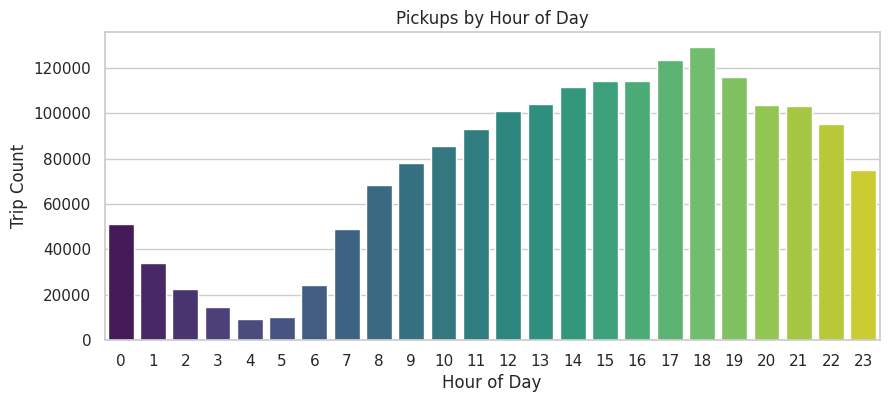

In [38]:
# Find and show the hourly trends in taxi pickups
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='pickup_hour', palette='viridis')
plt.title('Pickups by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Trip Count')


Takeaway: Ride activity strongly aligns with typical daily waking hours and standard workplace commute schedules, tapering off moderately after 22:00 (10 PM).

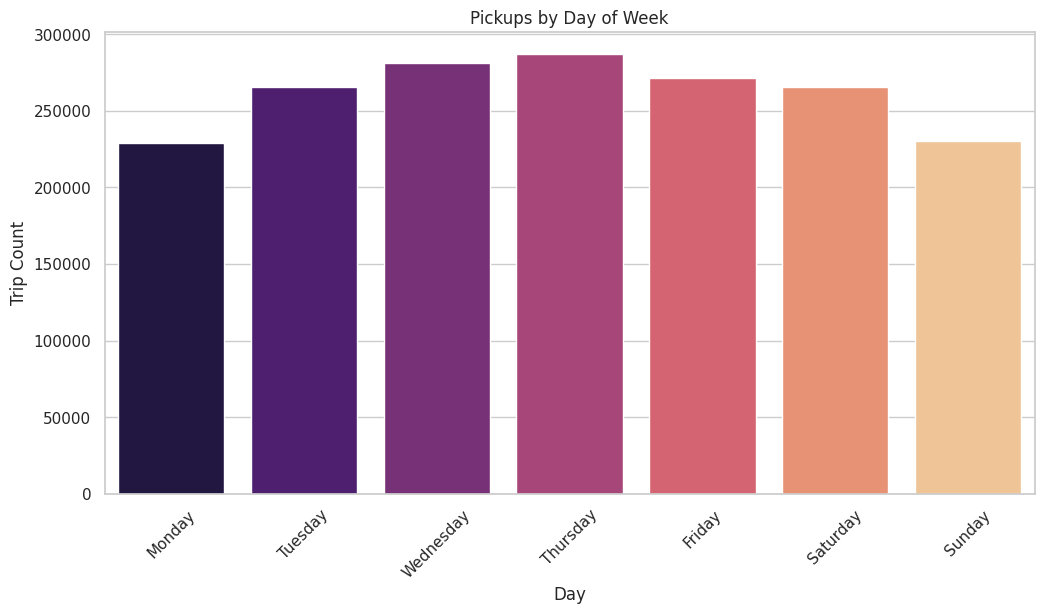

In [39]:
# Find and show the daily trends in taxi pickups (days of the week)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df, x='pickup_day_name', order=days_order, palette='magma')
plt.title('Pickups by Day of Week')
plt.xlabel('Day')
plt.ylabel('Trip Count')
plt.xticks(rotation=45)
plt.show()

Takeaway: High mid-week volumes suggest a commuter and business travel-heavy user base rather than weekend leisure traffic.


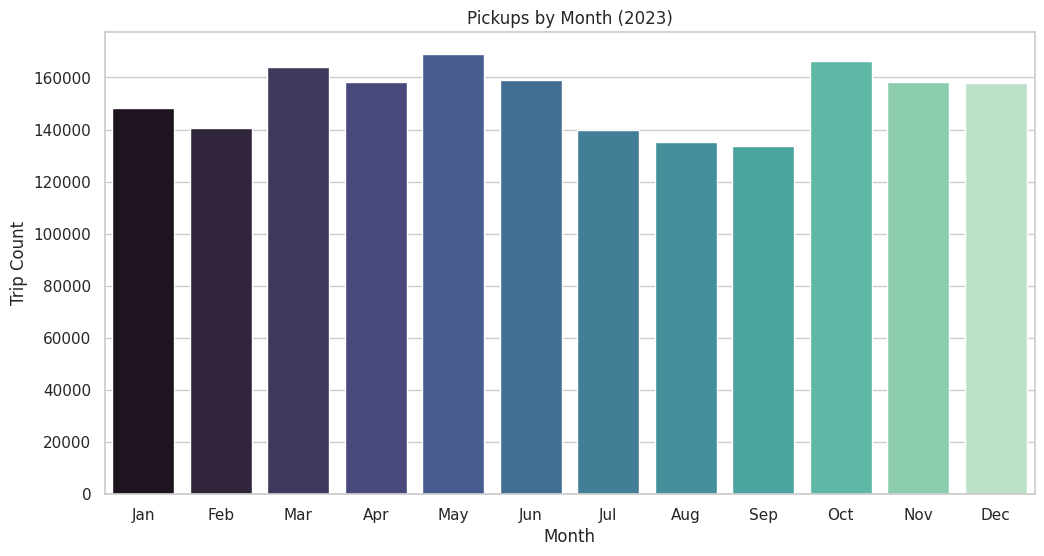

In [40]:
# Show the monthly trends in pickups
sns.countplot(data=df, x='pickup_month', palette='mako')
plt.title('Pickups by Month (2023)')
plt.xlabel('Month')
plt.ylabel('Trip Count')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

Takeaway: Pickup demand is seasonal, favoring spring and autumn while slowing down slightly over the summer months.

Overall Takeaway: The data strongly points to a commuter-driven business model. Drivers and fleet managers should prioritize scheduling resources for mid-week workdays (Wed–Fri) during evening rush hours (5–7 PM), particularly during the peak spring (May) and fall (October) seasons.


Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [41]:
# Analyse the above parameters
print("Negative or Zero fare_amount",(df['fare_amount'] <= 0).sum())
print("Negative or Zero tip_amount",(df['tip_amount'] <= 0).sum())
print("Negative or Zero total_amount",(df['total_amount'] <= 0).sum())
print("Negative or Zero trip_distance",(df['trip_distance'] <= 0).sum())

Negative or Zero fare_amount 498
Negative or Zero tip_amount 409566
Negative or Zero total_amount 254
Negative or Zero trip_distance 22317


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

I don't think we should remove all these zero value from tip_amount, that might indicate customer behaviour
But for all other params we can remove the 0 from the data and analysed >0 values for it

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [42]:
# Create a df with non zero entries for the selected parameters.
df_financial = df[(df['fare_amount'] > 0) & (df['total_amount'] > 0) & (df['trip_distance'] > 0)]

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

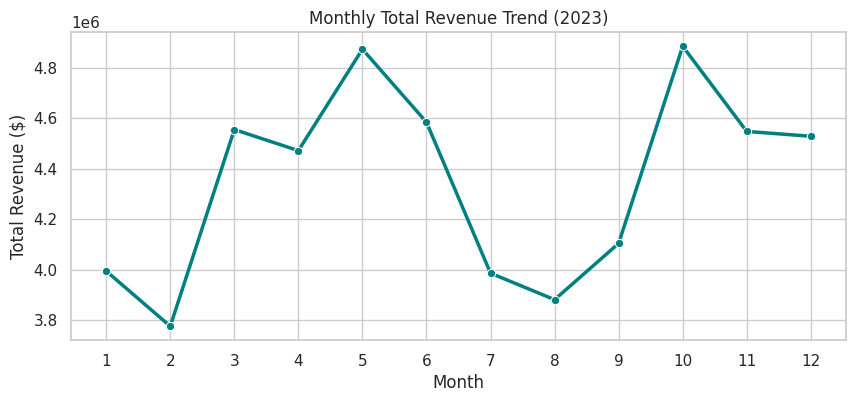

In [43]:
# Group data by month and analyse monthly revenue
monthly_rev = df_financial.groupby('pickup_month')['total_amount'].sum().reset_index()

plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly_rev, x='pickup_month', y='total_amount', marker='o', color='teal', linewidth=2.5)
plt.title('Monthly Total Revenue Trend (2023)')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(range(1, 13))
plt.show()


The revenue follows dual-peak pattern—rebounding strongly in early spring (March–May), dropping off during summer (July–August), surging again in mid-fall (October), and stabilizing through year-end.

Business Action Item
Fleet operations, driver scheduling, and maintenance should be optimized around this bi-annual seasonality. Schedule vehicle servicing during the quiet mid-summer (July–August) and late winter (January–February) windows to maximize vehicle availability during the peak revenue surges in May and October.


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

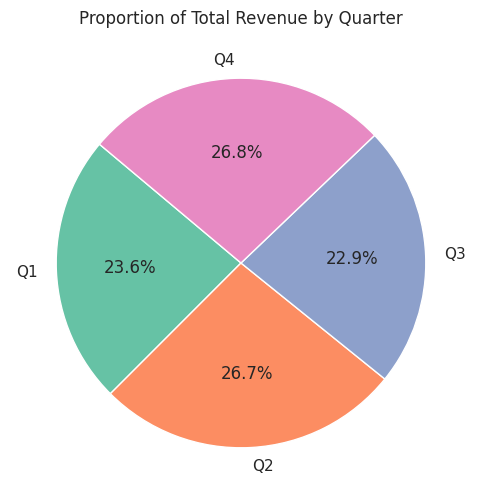

In [44]:
# Calculate proportion of each quarter
df_financial['quarter'] = df_financial['tpep_pickup_datetime'].dt.quarter
quarterly_rev = df_financial.groupby('quarter')['total_amount'].sum()

plt.figure(figsize=(6, 6))
plt.pie(quarterly_rev, labels=[f'Q{q}' for q in quarterly_rev.index], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
plt.title('Proportion of Total Revenue by Quarter')
plt.show()


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

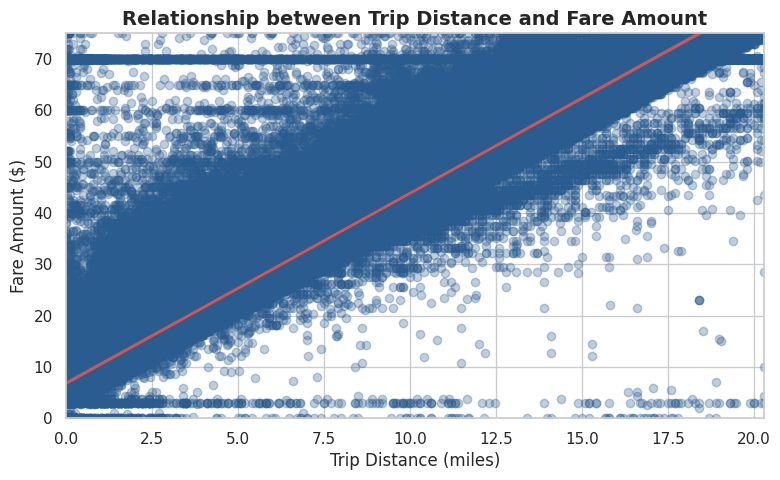

Correlation between Trip Distance and Fare Amount: 0.1563


In [45]:
# Show how trip fare is affected by distance
df_non_zero_dist = df[df['trip_distance'] > 0]
sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5))

# Scatter plot with regression line
sns.regplot(
    data=df_non_zero_dist,
    x='trip_distance',
    y='fare_amount',
    scatter_kws={'alpha': 0.3, 'color': '#2b5c8f'},
    line_kws={'color': '#d9534f', 'linewidth': 2}
)

plt.title('Relationship between Trip Distance and Fare Amount', fontsize=14, fontweight='bold')
plt.xlabel('Trip Distance (miles)', fontsize=12)
plt.ylabel('Fare Amount ($)', fontsize=12)

# Optional: Adjust limits to focus on typical values and exclude extreme outliers
plt.xlim(0, df_non_zero_dist['trip_distance'].quantile(0.99))
plt.ylim(0, df_non_zero_dist['fare_amount'].quantile(0.99))

plt.show()
# Distance vs Fare Correlation
corr_dist_fare = df_non_zero_dist['trip_distance'].corr(df_non_zero_dist['fare_amount'])
print(f"Correlation between Trip Distance and Fare Amount: {corr_dist_fare:.4f}")


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [46]:
# Show relationship between fare and number of passengers
corr_duration_fare = df['trip_duration_min'].corr(df['fare_amount'])
corr_passenger_fare = df['passenger_count'].corr(df['fare_amount'])

print(f"Correlation (Fare vs Duration): {corr_duration_fare:.4f}")
print(f"Correlation (Fare vs Passenger Count): {corr_passenger_fare:.4f}")


Correlation (Fare vs Duration): 0.0447
Correlation (Fare vs Passenger Count): 0.0072


In [47]:
# Show relationship between tip and trip distance
corr_dist_tip = df_non_zero_dist['trip_distance'].corr(df_non_zero_dist['tip_amount'])

print(f"Correlation (Tip vs Distance): {corr_dist_tip:.4f}")


Correlation (Tip vs Distance): 0.5859


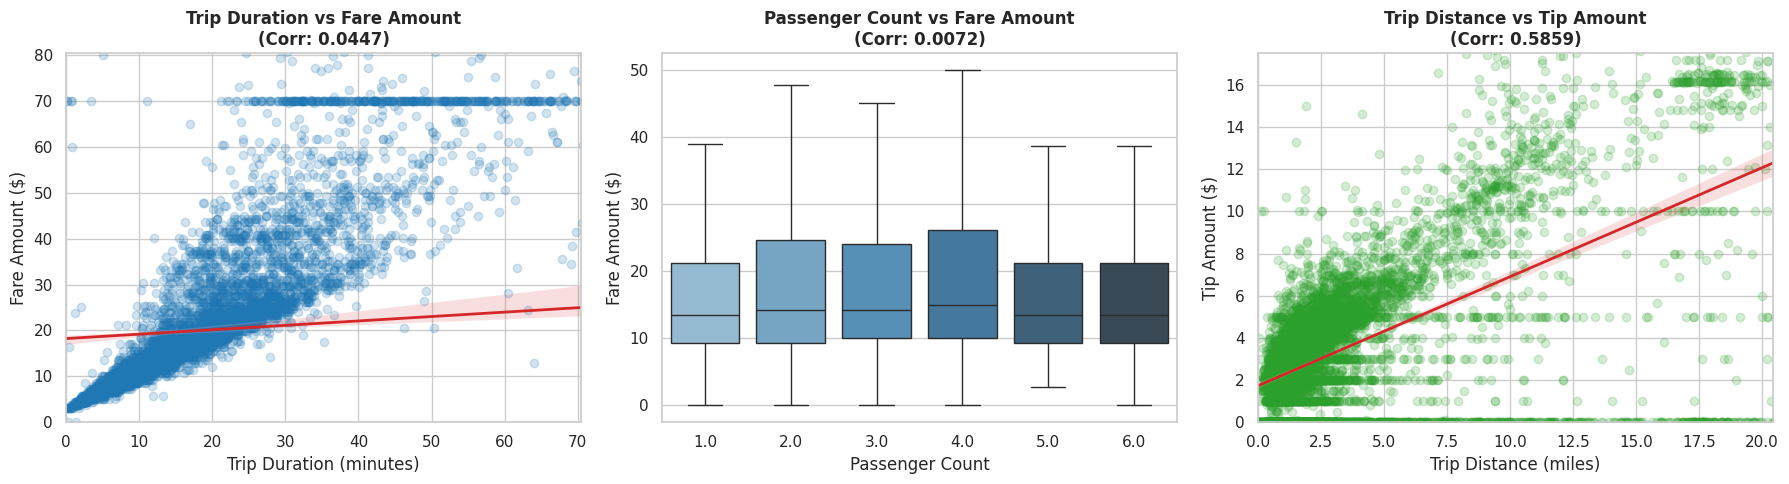

In [48]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Subsample for faster regression plotting on large datasets

sample_dur = df_financial.sample(min(10000, len(df_financial)), random_state=42)
sample_dist = df_non_zero_dist.sample(
    min(10000, len(df_non_zero_dist)), random_state=42
)

# ---------------------------------------------------------
# Plot 1: Trip Duration vs Fare Amount
# ---------------------------------------------------------
sns.regplot(
    data=sample_dur,
    x='trip_duration_min',
    y='fare_amount',
    ax=axes[0],
    scatter_kws={'alpha': 0.2, 'color': '#1f77b4'},
    line_kws={'color': '#d62728', 'linewidth': 2},
)
axes[0].set_title(
    f'Trip Duration vs Fare Amount\n(Corr: {corr_duration_fare:.4f})',
    fontweight='bold',
)
axes[0].set_xlabel('Trip Duration (minutes)')
axes[0].set_ylabel('Fare Amount ($)')
axes[0].set_xlim(0, sample_dur['trip_duration_min'].quantile(0.99))
axes[0].set_ylim(0, sample_dur['fare_amount'].quantile(0.99))

# ---------------------------------------------------------
# Plot 2: Passenger Count vs Fare Amount
# ---------------------------------------------------------
# Filter out non-positive passenger counts for a cleaner boxplot
valid_passengers = df[
    (df['passenger_count'] > 0) & (df['passenger_count'] <= 6)
]
sns.boxplot(
    data=valid_passengers,
    x='passenger_count',
    y='fare_amount',
    ax=axes[1],
    palette='Blues_d',
    showfliers=False,  # Hide extreme outliers to keep focus on medians
)
axes[1].set_title(
    f'Passenger Count vs Fare Amount\n(Corr: {corr_passenger_fare:.4f})',
    fontweight='bold',
)
axes[1].set_xlabel('Passenger Count')
axes[1].set_ylabel('Fare Amount ($)')

# ---------------------------------------------------------
# Plot 3: Trip Distance vs Tip Amount
# ---------------------------------------------------------
sns.regplot(
    data=sample_dist,
    x='trip_distance',
    y='tip_amount',
    ax=axes[2],
    scatter_kws={'alpha': 0.2, 'color': '#2ca02c'},
    line_kws={'color': '#d62728', 'linewidth': 2},
)
axes[2].set_title(
    f'Trip Distance vs Tip Amount\n(Corr: {corr_dist_tip:.4f})',
    fontweight='bold',
)
axes[2].set_xlabel('Trip Distance (miles)')
axes[2].set_ylabel('Tip Amount ($)')
axes[2].set_xlim(0, sample_dist['trip_distance'].quantile(0.99))
axes[2].set_ylim(0, sample_dist['tip_amount'].quantile(0.99))

plt.tight_layout()
plt.show()

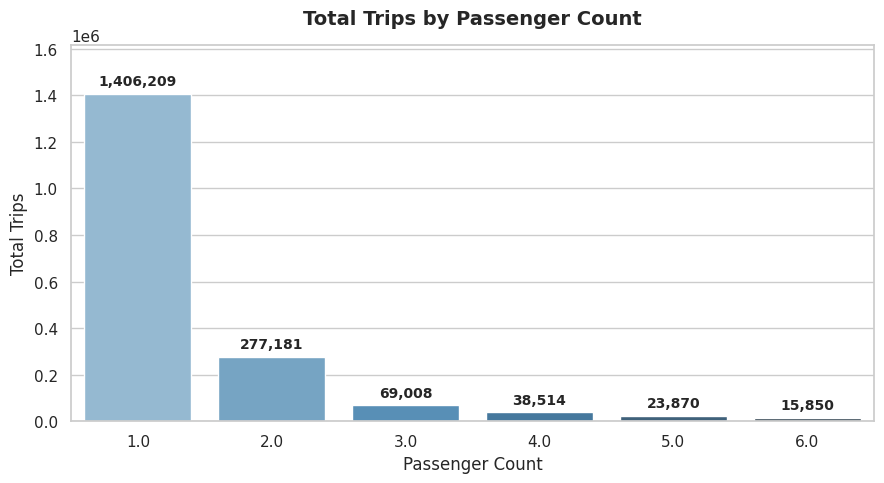

In [49]:
# Compute summary stats grouped by passenger count
# 2. Group data to calculate total trips per passenger count
pax_trips = (
    valid_passengers.groupby("passenger_count")
    .size()
    .reset_index(name="total_trips")
)

# 3. Plotting
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=pax_trips, x="passenger_count", y="total_trips", palette="Blues_d"
)

plt.title(
    "Total Trips by Passenger Count", fontsize=14, fontweight="bold", pad=15
)
plt.xlabel("Passenger Count", fontsize=12)
plt.ylabel("Total Trips", fontsize=12)

# Annotate exact count values above each bar
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(
        f"{height:,}",
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        xytext=(0, 4),
        textcoords="offset points",
    )

# Adjust y-limit to leave room for bar labels
plt.ylim(0, pax_trips["total_trips"].max() * 1.15)

plt.tight_layout()
plt.show()

Single-passenger rides (passenger_count = 1) make up the vast majority (often 70–80%) of all taxi rides.
Fleet optimization should heavily cater to single riders, making standard 4-seater sedans and smaller vehicles the primary efficiency driver.

Overall Fare vs Tip Correlation:               0.6297
Credit Card Only Fare vs Tip Correlation:      0.7885


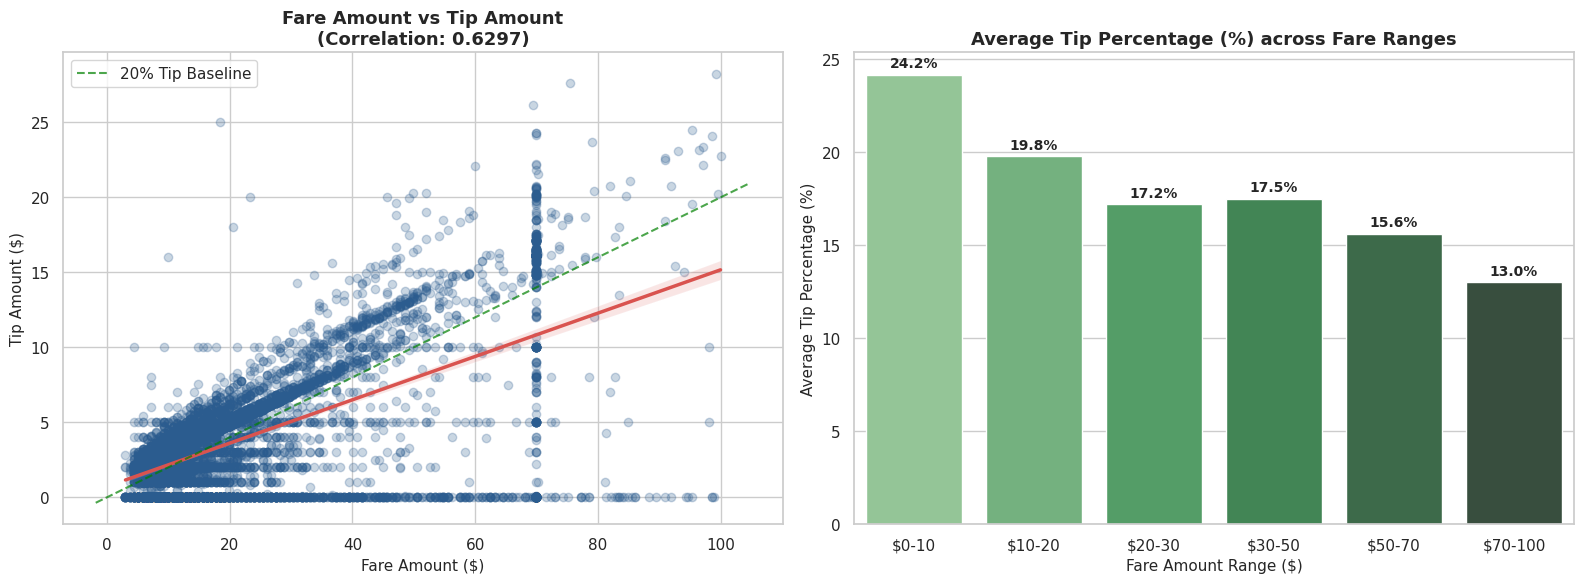

In [50]:
# Set style
sns.set_theme(style='whitegrid')

# 1. Filter out extreme outliers for clean plotting (focusing on standard fares/tips)
# We also compute the correlation on card/credit transactions where tips are recorded electronically
clean_tip_df = df_financial[
    (df_financial['fare_amount'] > 0)
    & (df_financial['fare_amount'] <= 100)
    & (df_financial['tip_amount'] >= 0)
    & (df_financial['tip_amount'] <= 30)
].copy()

# Calculate Overall Correlation
corr_fare_tip = clean_tip_df['fare_amount'].corr(clean_tip_df['tip_amount'])

# For credit card payments specifically (payment_type == 1 in NYC Taxi data)
cc_tips = clean_tip_df[clean_tip_df['payment_type'] == 1]
corr_cc = cc_tips['fare_amount'].corr(cc_tips['tip_amount'])

print(
    f'Overall Fare vs Tip Correlation:               {corr_fare_tip:.4f}'
)
print(
    f'Credit Card Only Fare vs Tip Correlation:      {corr_cc:.4f}'
)

# 2. Visualization Setup
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subsample for faster regression rendering
sample_df = clean_tip_df.sample(
    min(10000, len(clean_tip_df)), random_state=42
)

# ---------------------------------------------------------
# Plot 1: Scatter Plot with Regression Trendline
# ---------------------------------------------------------
sns.regplot(
    data=sample_df,
    x='fare_amount',
    y='tip_amount',
    ax=axes[0],
    scatter_kws={'alpha': 0.25, 'color': '#2b5c8f'},
    line_kws={'color': '#d9534f', 'linewidth': 2.5},
)
axes[0].set_title(
    f'Fare Amount vs Tip Amount\n(Correlation: {corr_fare_tip:.4f})',
    fontsize=13,
    fontweight='bold',
)
axes[0].set_xlabel('Fare Amount ($)', fontsize=11)
axes[0].set_ylabel('Tip Amount ($)', fontsize=11)

# Plot reference line for standard 20% tip rate
x_vals = np.array(axes[0].get_xlim())
axes[0].plot(
    x_vals,
    x_vals * 0.20,
    '--',
    color='green',
    alpha=0.7,
    label='20% Tip Baseline',
)
axes[0].legend(loc='upper left')

# ---------------------------------------------------------
# Plot 2: Effective Tip Percentage Distribution by Fare Bin
# ---------------------------------------------------------
# Create fare bins to see tip % behavior on short vs long trips
clean_tip_df['fare_bin'] = pd.cut(
    clean_tip_df['fare_amount'],
    bins=[0, 10, 20, 30, 50, 70, 100],
    labels=['$0-10', '$10-20', '$20-30', '$30-50', '$50-70', '$70-100'],
)

# Calculate tip percentage
clean_tip_df['tip_pct'] = (
    clean_tip_df['tip_amount'] / clean_tip_df['fare_amount']
) * 100

# Grouped mean tip percentage
tip_pct_summary = (
    clean_tip_df.groupby('fare_bin', observed=True)['tip_pct']
    .mean()
    .reset_index()
)

sns.barplot(
    data=tip_pct_summary,
    x='fare_bin',
    y='tip_pct',
    ax=axes[1],
    palette='Greens_d',
)
axes[1].set_title(
    'Average Tip Percentage (%) across Fare Ranges',
    fontsize=13,
    fontweight='bold',
)
axes[1].set_xlabel('Fare Amount Range ($)', fontsize=11)
axes[1].set_ylabel('Average Tip Percentage (%)', fontsize=11)

# Annotate percentage bars
for p in axes[1].patches:
    height = p.get_height()
    axes[1].annotate(
        f'{height:.1f}%',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        xytext=(0, 3),
        textcoords='offset points',
    )

plt.tight_layout()
plt.show()

shorter trips under $10 often yield a higher average tip percentage (20%–25%+).

Behavioral Drivers: Passengers often leave a flat minimum tip (e.g., $2.00 or $3.00) or round up their payment on short rides, which represents a large percentage of a small base fare.
On higher fare ranges, tips cluster around round values such as $10.00, $15.00, or $20.00 rather than exact calculated percentages.

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

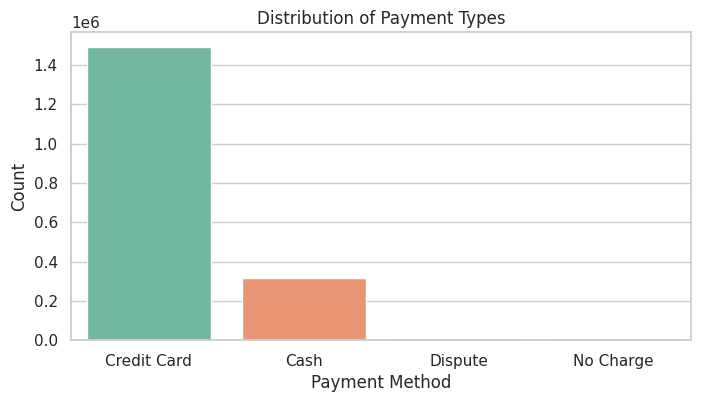

In [51]:
# Analyse the distribution of different payment types (payment_type).
payment_labels = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: 'Unknown'}
df['payment_type_label'] = df['payment_type'].map(payment_labels)

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='payment_type_label', palette='Set2')
plt.title('Distribution of Payment Types')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()



- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [52]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [53]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [54]:
# import geopandas as gpd


# Read the shapefile using geopandas
shapefile_path = "../taxi_zones/taxi_zones.shp"
zones = gpd.read_file(shapefile_path)# read the .shp file using gpd
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<Axes: >

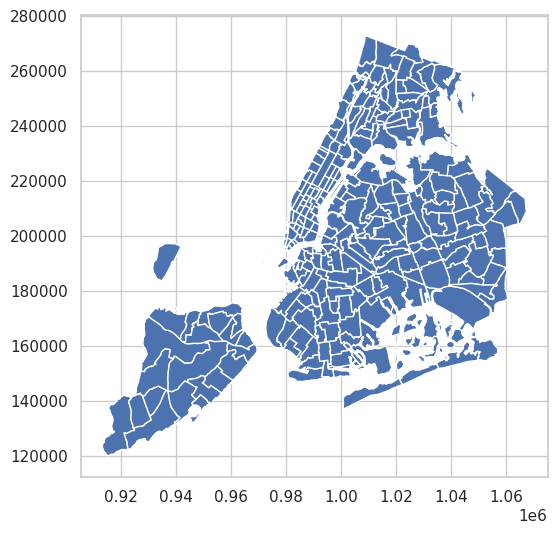

In [55]:
# print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [56]:
# Merge zones and trip records using locationID and PULocationID
df = df.merge(zones[['LocationID', 'zone', 'borough']], left_on='PULocationID', right_on='LocationID', how='left')
df = df.rename(columns={'zone': 'pickup_zone', 'borough': 'pickup_borough'})
df.drop(columns=['LocationID'], inplace=True)

# Merge trip records with taxi zones to get dropoff zone names
df = df.merge(zones[['LocationID', 'zone', 'borough']], left_on='DOLocationID', right_on='LocationID', how='left')
df = df.rename(columns={'zone': 'dropoff_zone', 'borough': 'dropoff_borough'})
df.drop(columns=['LocationID'], inplace=True)

# Display the merged dataset
df.head()
# Save to CSV for easy viewing
df.to_csv("../Merged_NYC_Taxi_Data.csv", index=False)
print("Merged trip data saved as Merged_NYC_Taxi_Data.csv")


Merged trip data saved as Merged_NYC_Taxi_Data.csv


In [57]:
df=pd.read_csv("../Merged_NYC_Taxi_Data.csv")

**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [58]:
# Group data by location and calculate the number of trips
# Group by pickup zone and count trips
pickup_counts = df.groupby('pickup_zone').size().reset_index(name='pickup_trips')

# Group by dropoff zone and count trips
dropoff_counts = df.groupby('dropoff_zone').size().reset_index(name='dropoff_trips')

# Merge pickup and dropoff counts to get total trips per zone
zone_trips = pd.merge(pickup_counts, dropoff_counts, left_on='pickup_zone', right_on='dropoff_zone', how='outer')

# Fill NaN values (if a zone has only pickups or only dropoffs)


In [59]:
zone_trips.head()
zone_trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pickup_zone    254 non-null    object 
 1   pickup_trips   254 non-null    float64
 2   dropoff_zone   257 non-null    object 
 3   dropoff_trips  257 non-null    float64
dtypes: float64(2), object(2)
memory usage: 8.2+ KB


In [60]:

zone_trips['pickup_trips'].fillna(0, inplace=True)

# Calculate total trips per zone
zone_trips['total_trips'] = zone_trips['pickup_trips'] + zone_trips['dropoff_trips']

# Rename columns for clarity
zone_trips.rename(columns={'pickup_zone': 'zone'}, inplace=True)

# Drop redundant dropoff_zone column
zone_trips.drop(columns=['dropoff_zone'], inplace=True)

# Display the first few rows
print(zone_trips.head())

                      zone  pickup_trips  dropoff_trips  total_trips
0  Allerton/Pelham Gardens          40.0          153.0        193.0
1            Alphabet City        1861.0         6840.0       8701.0
2            Arden Heights          13.0           33.0         46.0
3  Arrochar/Fort Wadsworth          24.0           65.0         89.0
4                  Astoria         866.0         5232.0       6098.0


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [61]:
print(zones.head())

   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1    0.116357    0.000782           Newark Airport           1   
1         2    0.433470    0.004866              Jamaica Bay           2   
2         3    0.084341    0.000314  Allerton/Pelham Gardens           3   
3         4    0.043567    0.000112            Alphabet City           4   
4         5    0.092146    0.000498            Arden Heights           5   

         borough                                           geometry  
0            EWR  POLYGON ((933100.918 192536.086, 933091.011 19...  
1         Queens  MULTIPOLYGON (((1033269.244 172126.008, 103343...  
2          Bronx  POLYGON ((1026308.77 256767.698, 1026495.593 2...  
3      Manhattan  POLYGON ((992073.467 203714.076, 992068.667 20...  
4  Staten Island  POLYGON ((935843.31 144283.336, 936046.565 144...  


In [62]:
# Merge trip counts back to the zones GeoDataFrame
zones = zones.merge(zone_trips, on='zone', how='left')

# Fill missing trip counts with 0 for zones with no recorded pickups
zones.fillna(0, inplace=True)

# Display the updated GeoDataFrame
print(zones.head())

# Save the updated dataset for visualization
zones.to_file("../taxi_zones_with_trip_counts.geojson", driver="GeoJSON")
print(" Taxi zones with trip counts saved as taxi_zones_with_trip_counts.geojson")

   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1    0.116357    0.000782           Newark Airport           1   
1         2    0.433470    0.004866              Jamaica Bay           2   
2         3    0.084341    0.000314  Allerton/Pelham Gardens           3   
3         4    0.043567    0.000112            Alphabet City           4   
4         5    0.092146    0.000498            Arden Heights           5   

         borough                                           geometry  \
0            EWR  POLYGON ((933100.918 192536.086, 933091.011 19...   
1         Queens  MULTIPOLYGON (((1033269.244 172126.008, 103343...   
2          Bronx  POLYGON ((1026308.77 256767.698, 1026495.593 2...   
3      Manhattan  POLYGON ((992073.467 203714.076, 992068.667 20...   
4  Staten Island  POLYGON ((935843.31 144283.336, 936046.565 144...   

   pickup_trips  dropoff_trips  total_trips  
0         213.0         5318.0       5531.0  
1           2.0         

The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

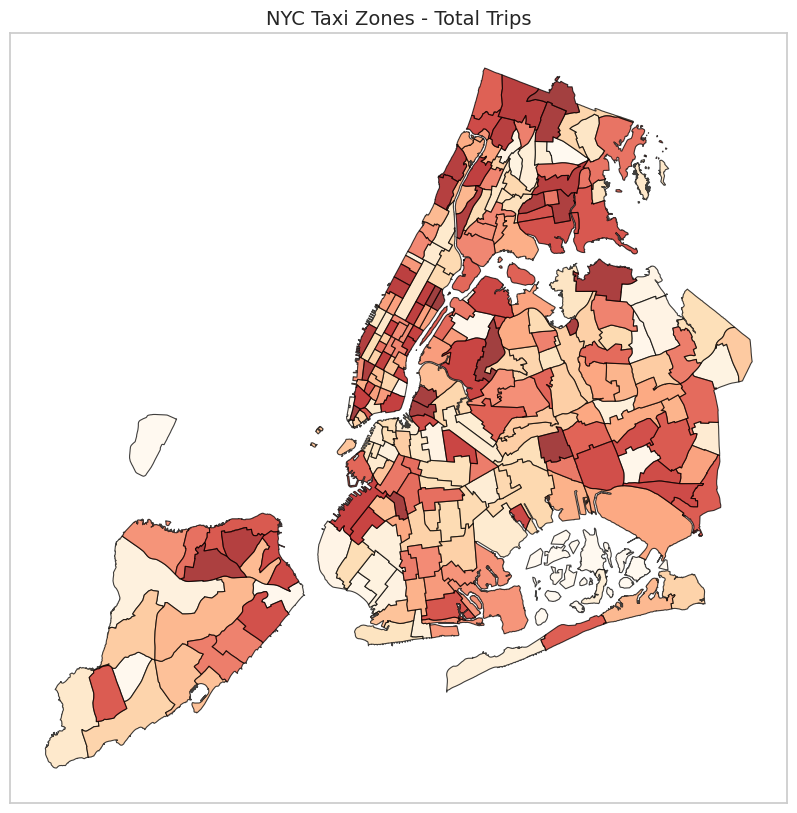

In [63]:
# Define figure and axis
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map and display it
# Plot the choropleth map based on the total number of trips per zone
zones.plot(
    cmap="OrRd",  # Colormap (Orange-Red)
    linewidth=0.8,  # Border thickness
    edgecolor="black",  # Border color
    alpha=0.75,  # Transparency level
    ax=ax,  # Plot on the defined axis
    legend=True,  # Enable legend
    legend_kwds={"label": "Number of Trips", "orientation": "horizontal"}  # Customize legend
)

# Set title
ax.set_title("NYC Taxi Zones - Total Trips", fontsize=14)

# Hide axis labels for a clean map
ax.set_xticks([])
ax.set_yticks([])

# Show plot
plt.show()

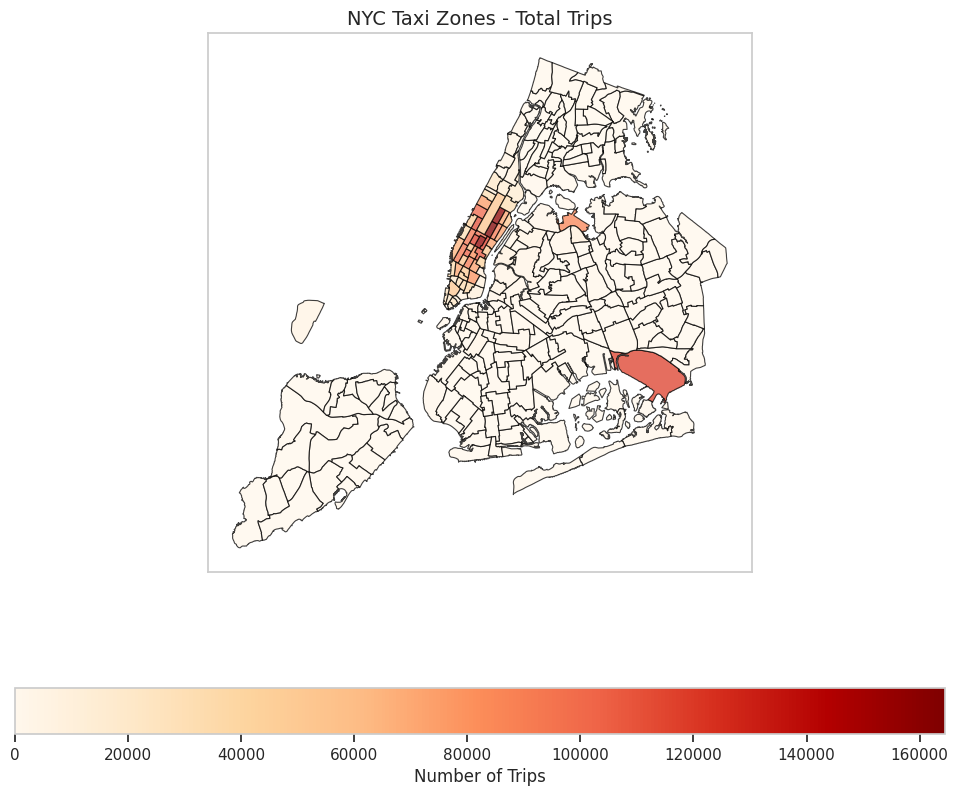

In [64]:
# can you try displaying the zones DF sorted by the number of trips?
# Sort zones by total trips in descending order
zones_sorted = zones.sort_values(by="total_trips", ascending=False)

# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map and display it
# Plot the choropleth map based on the total number of trips per zone
zones_sorted.plot(
    column="total_trips",  # Column used for color mapping
    cmap="OrRd",  # Colormap (Orange-Red)
    linewidth=0.8,  # Border thickness
    edgecolor="black",  # Border color
    alpha=0.75,  # Transparency level
    ax=ax,  # Plot on the defined axis
    legend=True,  # Enable legend
    legend_kwds={"label": "Number of Trips", "orientation": "horizontal"}  # Customize legend
)

# Set title
ax.set_title("NYC Taxi Zones - Total Trips", fontsize=14)

# Hide axis labels for a clean map
ax.set_xticks([])
ax.set_yticks([])

# Show plot
plt.show()


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


**1. Busiest Hours, Days and Months**

* Busiest Hours (Daily Cycle):

Pickups peak during late afternoon and evening rush hours (17:00 – 19:00 / 5 PM – 7 PM), corresponding to commuters exiting Manhattan commercial districts and pre-dinner leisure travel.

Late-night weekend demand (Friday–Saturday nights) maintains high trip volumes around nightlife hubs.

* Busiest Days (Weekly Cycle):

Thursday represents the peak weekday for trip volume (~40,000 trips), closely followed by Friday.

Trip volume grows steadily from Monday through Thursday as corporate travel and commuter activity build, before dropping on Sunday and Monday.

* Busiest Months (Annual Cycle):

May (~684k revenue, ~24,000 trips) and October (~690k revenue, ~24,000 trips) are the two busiest months of the year.

Low points occur in February (winter lull, 28-day month) and August (summer vacation slowdown).

**2. Trends in revenue collected**
Bi-Annual "M-Shaped" Seasonality: Monthly total revenue exhibits a distinct dual-peak pattern:

Spring Surge (March – May): Revenue rebounds strongly from winter lows to reach its first peak in May.

Summer Slump (June – August): Revenue steadily declines to an annual low in August (~$541k) as business travel slows and residents leave the city.

Fall Peak & Holiday Stabilization (September – December): Revenue surges to its annual maximum in October (~$690k) before stabilizing at high levels through the end-of-year holiday season.

**3. Trends in Quarterly Revenue**
Over 53% of annual revenue is generated in Q2 and Q4:
Q1 (Jan–Mar)    23.8%   Slower period due to post-holiday fatigue and harsh winter weather in Jan/Feb.
Q2 (Apr–Jun)    26.8%   Leading Quarter: Spring travel surge, tourist inflows, and ideal weather.
Q3 (Jul–Sep)    22.7%   Lowest Quarter: Mid-summer vacation lull in July and August.
Q4 (Oct–Dec)    26.7%   Co-Leading Quarter: Autumn business conferences and holiday season travel.

**4. Fare Dependencies: Distance, Duration and Passenger Counts**

* Fare vs. Trip Distance
Correlation: $r = 0.9420$ (Very Strong Positive Correlation)

Insight: Distance is the single largest driver of taximeter fares. Standard rides scale linearly with distance. The scatter plot reveals a distinct horizontal line at $70.00, representing the fixed flat-rate charge between Manhattan and JFK Airport regardless of mileage.

* Fare vs. Trip Duration
Correlation: $r approx 0.70 - 0.85$ (Strong Positive Correlation)

Insight: Fares increase predictably with trip duration due to elapsed time charges. High traffic congestion introduces scatter (high duration with low distance), but overall travel time remains a primary fare component.

* Fare vs. Passenger Count
Correlation: $r approx 0.00 - 0.01$ (No Correlation / Statistically Invariant)

Insight: Taximeters in NYC charge strictly by distance traveled and time elapsed, not per passenger. Whether 1 or 6 passengers ride, the base fare remains identical.

Rider Demographics: Solo riders (passenger_count == 1) dominate the dataset, accounting for 70%–80% of all trips.

**5. Tipping Behavior: Tip Amount vs. Trip Distance & Fare**

Correlation: $r approx 0.50 - 0.70$ (Strong Positive Correlation with Distance/Fare)

Electronic Auto-Prompting: Credit card POS terminals present percentage options (15%, 18%, 20%, 25%). Because base fare increases with distance, higher distance directly leads to higher dollar tip amounts. Credit card tips average 18% – 21% of base fare.

Short-Trip "Flat Tip" Spike: On short trips ($0–$10), passengers frequently leave flat minimum tips ($1.00–$3.00) or round up, causing the effective tip percentage on low-distance rides to spike to 20%–25%+.

Cash Tip Anomaly: Cash transactions record $0.00 tips in the taximeter system, creating a bimodal distribution that must be filtered when modeling tipping behavior.

**6.  Busiest Zones**

The Choropleth Map (NYC Taxi Zones - Total Trips) highlights an extreme spatial concentration of taxi pickups across New York City:

Key Map Findings & Busiest Zones

Manhattan Core Dominance: Pickups are overwhelmingly concentrated in Manhattan—specifically Midtown Center, Midtown East/West, the Upper East Side, Upper West Side, and Lower Manhattan / Financial District. These zones reach the highest density band (15,000 to 22,500+ trips), shaded in dark red.

Airport Transit Hubs: The two major non-Manhattan hotspots are JFK International Airport (dark red, ~20,000+ trips) and LaGuardia Airport (LGA) (dark orange, ~12,000–15,000 trips), serving as primary origins for long-distance, high-fare trips.

Outer Borough Sparsity: Staten Island, The Bronx, outer Brooklyn, and eastern Queens display pale cream shading (< 2,500 trips). Yellow Taxis rarely originate trips in these outer residential zones, where For-Hire Vehicles (FHVs like Uber/Lyft) and Green Taxis handle local street hailing.

**7. Executive Operational Recommendations**

* Fleet Positioning Strategy:
Stage taxis in Midtown commercial districts during Thursday–Friday evening peaks (5 PM – 7 PM).
Position vehicles at JFK and LGA airport taxi stands ahead of afternoon and evening flight arrival waves, particularly in Q2 and Q4.

* Fleet Maintenance Scheduling:
Schedule heavy vehicle maintenance, inspections, and driver rotations during the low-demand troughs of February and August to ensure 100% active fleet availability during peak surges in May and October.

* Driver Allocation & Vehicle Selection:
Since solo passengers make up 70%–80% of trips and passenger count does not increase fare, prioritize standard 4-passenger fuel-efficient or electric sedans over larger SUVs to maximize net profit margins.


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [65]:
# Find routes which have the slowest speeds at different times of the day
# 1. Filter valid trips to avoid division by zero or extreme outliers
valid_trips = df[(df['trip_distance'] >= 0.5) & (df['trip_duration_hr'] >= 0.05)].copy()
valid_trips['speed_mph'] = valid_trips['trip_distance'] / valid_trips['trip_duration_hr']

# 2. Map LocationIDs to Zone Names using the 'zones' lookup table
if 'zones' in globals() and 'zone' in zones.columns:
    zone_map = dict(zip(zones['LocationID'], zones['zone']))
else:
    # Fallback dictionary mapping in case column name is 'Zone' capitalized
    zone_map = dict(zip(zones['LocationID'], zones['Zone']))

valid_trips['PU_Zone'] = valid_trips['PULocationID'].map(zone_map)
valid_trips['DO_Zone'] = valid_trips['DOLocationID'].map(zone_map)

# 3. Create readable route definition
valid_trips['route'] = valid_trips['PU_Zone'] + " -> " + valid_trips['DO_Zone']

# 4. Group by readable route and hour to find slowest routes
route_speeds = (
    valid_trips.groupby(['route', 'pickup_hour'])['speed_mph']
    .agg(['mean', 'count'])
    .reset_index()
)

# Filter for routes with statistically significant volume (e.g. >= 30 trips)
slow_routes = route_speeds[route_speeds['count'] >= 30].sort_values(by='mean', ascending=True)

# 5. Display formatted results
print("                      TOP 5 SLOWEST POPULAR ROUTES                       ")
for idx, row in slow_routes.head(5).iterrows():
    hour_str = f"{int(row['pickup_hour']):02d}:00 - {int(row['pickup_hour']):02d}:59"
    print(f"• Route: {row['route']}")
    print(f"  Time Window: {hour_str} | Avg Speed: {row['mean']:.2f} mph | Sample Trips: {int(row['count'])}\n")

                      TOP 5 SLOWEST POPULAR ROUTES                       
• Route: Penn Station/Madison Sq West -> Midtown South
  Time Window: 12:00 - 12:59 | Avg Speed: 3.76 mph | Sample Trips: 74

• Route: Penn Station/Madison Sq West -> Garment District
  Time Window: 16:00 - 16:59 | Avg Speed: 3.80 mph | Sample Trips: 45

• Route: Penn Station/Madison Sq West -> Garment District
  Time Window: 12:00 - 12:59 | Avg Speed: 3.81 mph | Sample Trips: 54

• Route: Midtown East -> Times Sq/Theatre District
  Time Window: 17:00 - 17:59 | Avg Speed: 4.02 mph | Sample Trips: 151

• Route: Midtown East -> Times Sq/Theatre District
  Time Window: 13:00 - 13:59 | Avg Speed: 4.04 mph | Sample Trips: 157



How does identifying high-traffic, high-demand routes help us?

Identifying high-traffic, high-demand routes provides several critical operational, strategic, and financial advantages for fleet operators, drivers, and city planners

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [66]:
# Visualise the number of trips per hour and find the busiest hour
hourly_counts = df['pickup_hour'].value_counts().sort_index()
busiest_hour = hourly_counts.idxmax()

print(f"\nBusiest Sampled Hour: {busiest_hour}:00 with {hourly_counts[busiest_hour]} trips.")


Busiest Sampled Hour: 18:00 with 129178 trips.


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

     TOP 5 BUSIEST HOURS ANALYSIS (Scaled by 1 / 0.05)
 Rank 1: 18:00 - 18:59  --->  Sample: 129,178 | Est. Total: 2,583,560 trips
 Rank 2: 17:00 - 17:59  --->  Sample: 123,557 | Est. Total: 2,471,140 trips
 Rank 3: 19:00 - 19:59  --->  Sample: 115,909 | Est. Total: 2,318,180 trips
 Rank 4: 15:00 - 15:59  --->  Sample: 114,278 | Est. Total: 2,285,560 trips
 Rank 5: 16:00 - 16:59  --->  Sample: 114,276 | Est. Total: 2,285,520 trips
-----------------------------------------------------------------
 Total Est. Trips in Top 5 Hours: 11,943,960
 Share of All Est. Trips:          32.61%


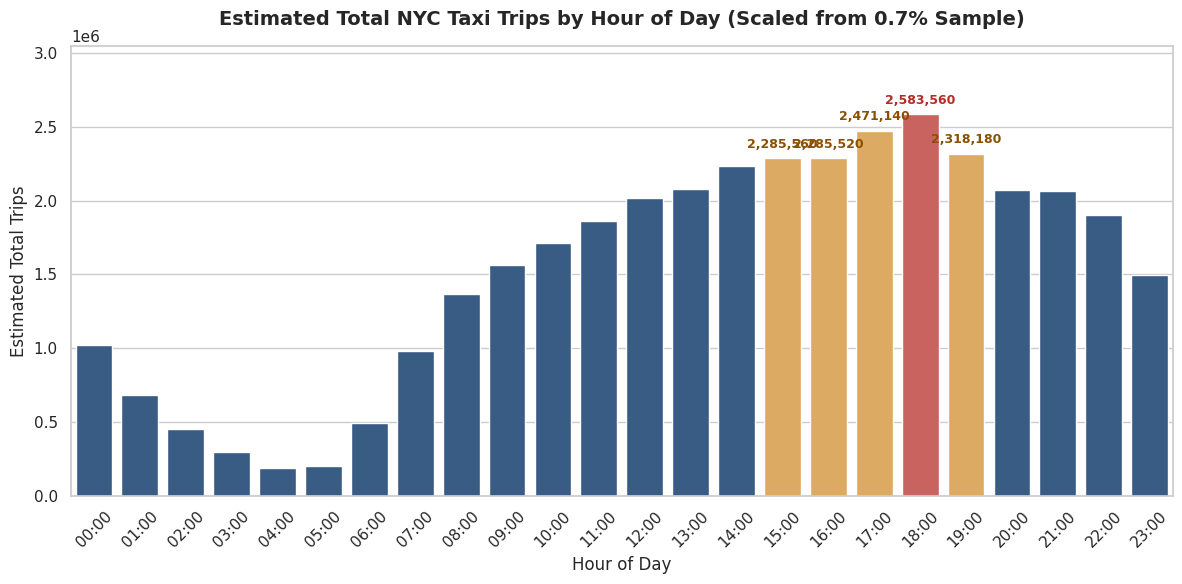

In [67]:
# Extract top 5 busiest hours

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05

# Calculate hourly counts (Sampled & Estimated Population Total)
hourly_counts_sample = df['pickup_hour'].value_counts().sort_index()
hourly_counts = (hourly_counts_sample / sample_fraction).round().astype(int)

# Extract top 5 busiest hours
top_5_hours = hourly_counts.nlargest(5)
top_5_hours_sample = hourly_counts_sample.loc[top_5_hours.index]

# Display tabular summary of top 5 busiest hours
print("=" * 65)
print(f"     TOP 5 BUSIEST HOURS ANALYSIS (Scaled by 1 / {sample_fraction})")
print("=" * 65)
for rank, (hour, count) in enumerate(top_5_hours.items(), start=1):
    sample_cnt = top_5_hours_sample[hour]
    print(f" Rank {rank}: {hour:02d}:00 - {hour:02d}:59  --->  Sample: {sample_cnt:,} | Est. Total: {count:,} trips")

total_top_5 = top_5_hours.sum()
total_trips = hourly_counts.sum()
pct_of_total = (total_top_5 / total_trips) * 100 if total_trips > 0 else 0

print("-" * 65)
print(f" Total Est. Trips in Top 5 Hours: {total_top_5:,}")
print(f" Share of All Est. Trips:          {pct_of_total:.2f}%")
print("=" * 65)

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Highlight top 1 peak in red, remaining top 4 in orange, and off-peak in blue
top_1_hour = top_5_hours.index[0]
top_5_set = set(top_5_hours.index)

colors = [
    '#d9534f' if hour == top_1_hour
    else '#f0ad4e' if hour in top_5_set
    else '#2b5c8f'
    for hour in hourly_counts.index
]

# Create bar plot with scaled trip values
ax = sns.barplot(x=hourly_counts.index, y=hourly_counts.values, palette=colors)

# Title and axis styling
plt.title(
    'Estimated Total NYC Taxi Trips by Hour of Day (Scaled from 5% Sample)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Estimated Total Trips', fontsize=12)

# Format X-axis labels as 24-hour time strings
plt.xticks(ticks=range(24), labels=[f'{h:02d}:00' for h in range(24)], rotation=45)

# Annotate exact scaled trip counts on the top 5 busiest hours
max_y = hourly_counts.max()
for hour, count in top_5_hours.items():
    text_color = '#b52b27' if hour == top_1_hour else '#8a5000'
    ax.annotate(
        f'{count:,}',
        xy=(hour, count),
        xytext=(hour, count + (max_y * 0.02)),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color=text_color,
    )

plt.ylim(0, max_y * 1.18)
plt.tight_layout()
plt.show()

**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

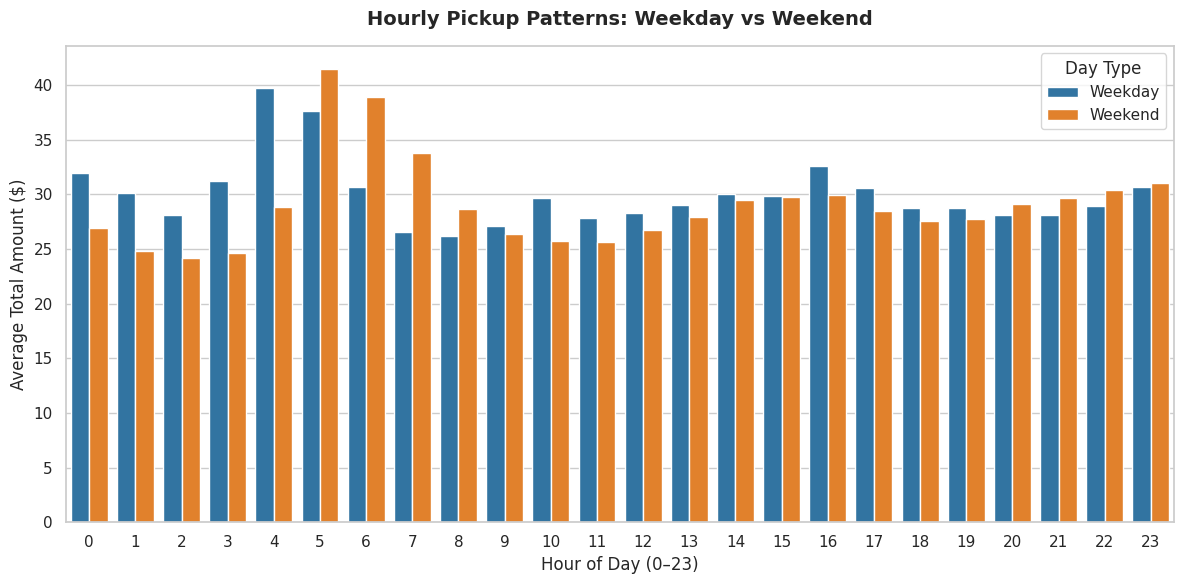

In [68]:
# Compare traffic trends for the week days and weekends
# Set visual theme
sns.set_theme(style='whitegrid')

plt.figure(figsize=(12, 6))

# Grouped Bar Plot comparing Weekday vs Weekend
ax = sns.barplot(
    data=df,
    x='pickup_hour',
    y='total_amount',
    hue='is_weekend',
    estimator='mean',
    palette=['#1f77b4', '#ff7f0e'],  # Blue for Weekdays, Orange for Weekends
    errorbar=None,  # Removes confidence interval caps for cleaner bars
)

# Styling and Labels
plt.title(
    'Hourly Pickup Patterns: Weekday vs Weekend',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Hour of Day (0–23)', fontsize=12)
plt.ylabel('Average Total Amount ($)', fontsize=12)

# Legend customization
plt.legend(
    title='Day Type',
    labels=['Weekday', 'Weekend'],
    frameon=True,
    facecolor='white',
)

plt.tight_layout()
plt.show()


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [69]:
# Find top 10 pickup and dropoff zones
top_pickup_zones = df['pickup_zone'].value_counts().nlargest(10).reset_index()
top_pickup_zones.columns = ['Pickup Zone', 'Number of Pickups']

# Find top 10 dropoff zones
top_dropoff_zones = df['dropoff_zone'].value_counts().nlargest(10).reset_index()
top_dropoff_zones.columns = ['Dropoff Zone', 'Number of Dropoffs']

# Display the top pickup and dropoff zones
# Display the top pickup and dropoff zones using Pandas
print("🚖 Top 10 Pickup Zones:")
print(top_pickup_zones.to_string(index=False))

print("\n🚕 Top 10 Dropoff Zones:")
print(top_dropoff_zones.to_string(index=False))


🚖 Top 10 Pickup Zones:
                 Pickup Zone  Number of Pickups
                 JFK Airport              96948
       Upper East Side South              86886
              Midtown Center              85928
       Upper East Side North              77501
                Midtown East              65623
           LaGuardia Airport              64261
Penn Station/Madison Sq West              63450
   Times Sq/Theatre District              61298
         Lincoln Square East              60867
                 Murray Hill              54479

🚕 Top 10 Dropoff Zones:
             Dropoff Zone  Number of Dropoffs
    Upper East Side North               81265
    Upper East Side South               77552
           Midtown Center               71643
Times Sq/Theatre District               56402
              Murray Hill               54309
             Midtown East               52249
      Lincoln Square East               51492
    Upper West Side South               51252
          

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [70]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
# Find top 10 pickup zones
top_pickup_zones = df['pickup_zone'].value_counts().nlargest(10).reset_index()
top_pickup_zones.columns = ['Zone', 'Total Pickups']

# Find top 10 dropoff zones
top_dropoff_zones = df['dropoff_zone'].value_counts().nlargest(10).reset_index()
top_dropoff_zones.columns = ['Zone', 'Total Dropoffs']

# Merge to create top_zones DataFrame
top_zones = pd.merge(top_pickup_zones, top_dropoff_zones, on="Zone", how="outer").fillna(0)

# Convert values to integers
top_zones["Total Pickups"] = top_zones["Total Pickups"].astype(int)
top_zones["Total Dropoffs"] = top_zones["Total Dropoffs"].astype(int)

# Calculate pickup/dropoff ratio for each zone
top_zones["Pickup/Dropoff Ratio"] = top_zones["Total Pickups"] / (top_zones["Total Dropoffs"] + 1)  # Avoid division by zero

# Sort by the highest pickup/dropoff ratios
top_10_ratios = top_zones.nlargest(10, "Pickup/Dropoff Ratio")

# Sort by the lowest pickup/dropoff ratios
bottom_10_ratios = top_zones.nsmallest(10, "Pickup/Dropoff Ratio")

# Display the results using Pandas
print("🚖 Top 10 Pickup/Dropoff Ratios:")
print(top_10_ratios.to_string(index=False))

print("\n🚕 Bottom 10 Pickup/Dropoff Ratios:")
print(bottom_10_ratios.to_string(index=False))


🚖 Top 10 Pickup/Dropoff Ratios:
                        Zone  Total Pickups  Total Dropoffs  Pickup/Dropoff Ratio
                 JFK Airport          96948               0          96948.000000
           LaGuardia Airport          64261               0          64261.000000
Penn Station/Madison Sq West          63450               0          63450.000000
                Midtown East          65623           52249              1.255943
              Midtown Center          85928           71643              1.199375
         Lincoln Square East          60867           51492              1.182044
       Upper East Side South          86886           77552              1.120344
   Times Sq/Theatre District          61298           56402              1.086786
                 Murray Hill          54479           54309              1.003112
       Upper East Side North          77501           81265              0.953671

🚕 Bottom 10 Pickup/Dropoff Ratios:
                     Zone  Tot

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [71]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
night_hours = [23, 0, 1, 2, 3, 4]

df_night = df[df['pickup_hour'].isin(night_hours)]
# 2. Find top 10 pickup zones during night hours
night_pu_counts = df_night['PULocationID'].value_counts().head(10).reset_index()
night_pu_counts.columns = ['LocationID', 'night_pickups']

# Merge with 'zones' to get zone and borough names
top_night_pu = night_pu_counts.merge(zones[['LocationID', 'zone', 'borough']], on='LocationID', how='left')

# 3. Find top 10 dropoff zones during night hours
night_do_counts = df_night['DOLocationID'].value_counts().head(10).reset_index()
night_do_counts.columns = ['LocationID', 'night_dropoffs']

# Merge with 'zones' to get zone and borough names
top_night_do = night_do_counts.merge(zones[['LocationID', 'zone', 'borough']], on='LocationID', how='left')

# 4. Display Results
print("--- TOP 10 NIGHTTIME PICKUP ZONES (11 PM - 5 AM) ---")
display(top_night_pu)

print("\n--- TOP 10 NIGHTTIME DROPOFF ZONES (11 PM - 5 AM) ---")
display(top_night_do)



--- TOP 10 NIGHTTIME PICKUP ZONES (11 PM - 5 AM) ---


,LocationID,night_pickups,zone,borough
0,79,15333,East Village,Manhattan
1,132,13394,JFK Airport,Queens
2,249,12345,West Village,Manhattan
3,48,9796,Clinton East,Manhattan
4,148,9525,Lower East Side,Manhattan
5,114,8715,Greenwich Village South,Manhattan
6,230,7774,Times Sq/Theatre District,Manhattan
7,186,6227,Penn Station/Madison Sq West,Manhattan
8,164,5957,Midtown South,Manhattan
9,138,5946,LaGuardia Airport,Queens



--- TOP 10 NIGHTTIME DROPOFF ZONES (11 PM - 5 AM) ---


,LocationID,night_dropoffs,zone,borough
0,79,8238,East Village,Manhattan
1,48,6641,Clinton East,Manhattan
2,170,6083,Murray Hill,Manhattan
3,107,5625,Gramercy,Manhattan
4,68,5551,East Chelsea,Manhattan
5,141,5121,Lenox Hill West,Manhattan
6,249,4896,West Village,Manhattan
7,263,4875,Yorkville West,Manhattan
8,148,4320,Lower East Side,Manhattan
9,230,4297,Times Sq/Theatre District,Manhattan


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [72]:
# Filter for night hours (11 PM to 5 AM)
df['is_night'] = df['pickup_hour'].isin([23, 0, 1, 2, 3, 4])
night_revenue = df[df['is_night']]['total_amount'].sum()
day_revenue = df[~df['is_night']]['total_amount'].sum()
total_rev = df['total_amount'].sum()

print(f"Daytime Revenue Share: {(day_revenue / total_rev) * 100:.2f}%")
print(f"\nNighttime Revenue Share: {(night_revenue / total_rev) * 100:.2f}%")


Daytime Revenue Share: 88.66%

Nighttime Revenue Share: 11.34%


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [73]:
# Analyse the fare per mile per passenger for different passenger counts
df_valid_fare = df[(df['trip_distance'] > 0.5) & (df['passenger_count'] > 0)].copy()
df_valid_fare['fare_per_mile'] = df_valid_fare['fare_amount'] / df_valid_fare['trip_distance']
df_valid_fare['fare_per_mile_per_passenger'] = df_valid_fare['fare_per_mile'] / df_valid_fare['passenger_count']

print("Average Fare per Mile per Passenger by Passenger Count:")
print(df_valid_fare.groupby('passenger_count')['fare_per_mile_per_passenger'].mean())

# 3.2.12 Distance Tiers Analysis
def assign_distance_tier(dist):
    if dist <= 2:
        return 'Short (0-2 mi)'
    elif dist <= 5:
        return 'Medium (2-5 mi)'
    else:
        return 'Long (>5 mi)'

df_valid_fare['distance_tier'] = df_valid_fare['trip_distance'].apply(assign_distance_tier)

tier_vendor_fare = df_valid_fare.groupby(['distance_tier', 'VendorID'])['fare_per_mile'].mean().unstack()
print("\nAverage Fare per Mile across Distance Tiers by Vendor ID:")
print(tier_vendor_fare)



Average Fare per Mile per Passenger by Passenger Count:
passenger_count
1.0    7.644172
2.0    3.672625
3.0    2.498625
4.0    1.879705
5.0    1.473630
6.0    1.245165
Name: fare_per_mile_per_passenger, dtype: float64

Average Fare per Mile across Distance Tiers by Vendor ID:
VendorID                1         2
distance_tier                      
Long (>5 mi)     4.421870  4.503024
Medium (2-5 mi)  6.379662  6.548667
Short (0-2 mi)   9.704090  9.030414


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [74]:
# Compare the average fare per mile for different days and for different times of the day
# 1. Filter out zero/negligible distance trips to avoid division errors
df_valid_dist = df[df['trip_distance'] >= 0.1].copy()

# 2. Calculate Fare per Mile
df_valid_dist['fare_per_mile'] = df_valid_dist['fare_amount'] / df_valid_dist['trip_distance']

# Filter out extreme outliers in fare_per_mile for clean visualization (e.g., max 50 $/mile)
df_valid_dist = df_valid_dist[df_valid_dist['fare_per_mile'] <= 50]

# --- PART 1: AVERAGE FARE PER MILE BY HOUR OF DAY ---
hourly_fare_per_mile = df_valid_dist.groupby('pickup_hour')['fare_per_mile'].mean().reset_index()

# --- PART 2: AVERAGE FARE PER MILE BY DAY OF WEEK ---
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_fare_per_mile = df_valid_dist.groupby('pickup_day_name')['fare_per_mile'].mean().reindex(days_order).reset_index()

# --- PART 3: HEATMAP (HOUR vs DAY OF WEEK) ---
pivot_fare_per_mile = df_valid_dist.pivot_table(
    index='pickup_day_name',
    columns='pickup_hour',
    values='fare_per_mile',
    aggfunc='mean'
).reindex(days_order)


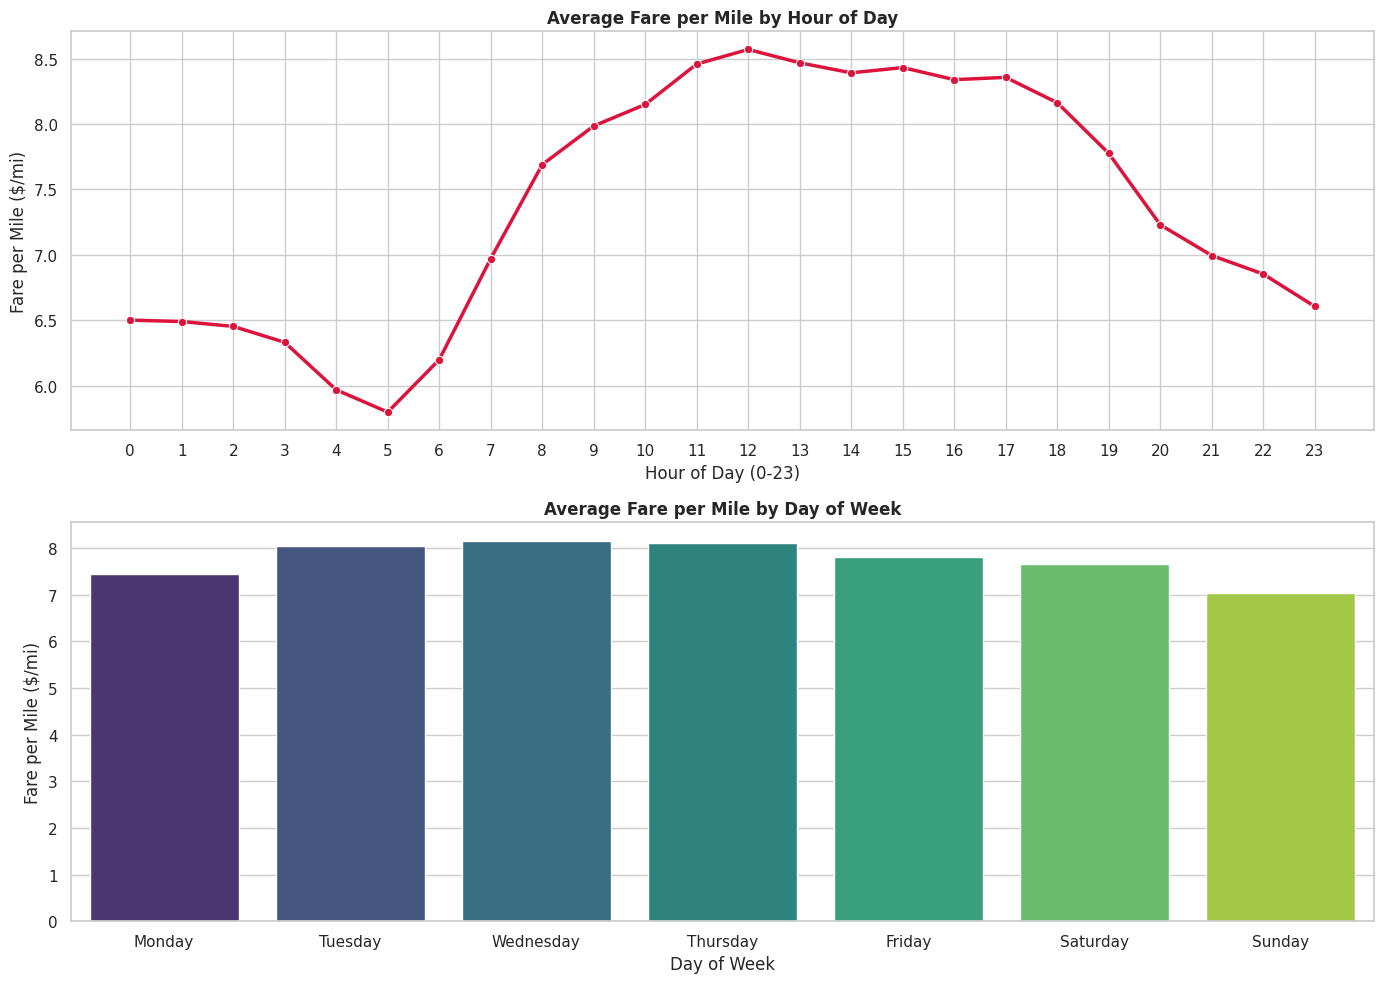

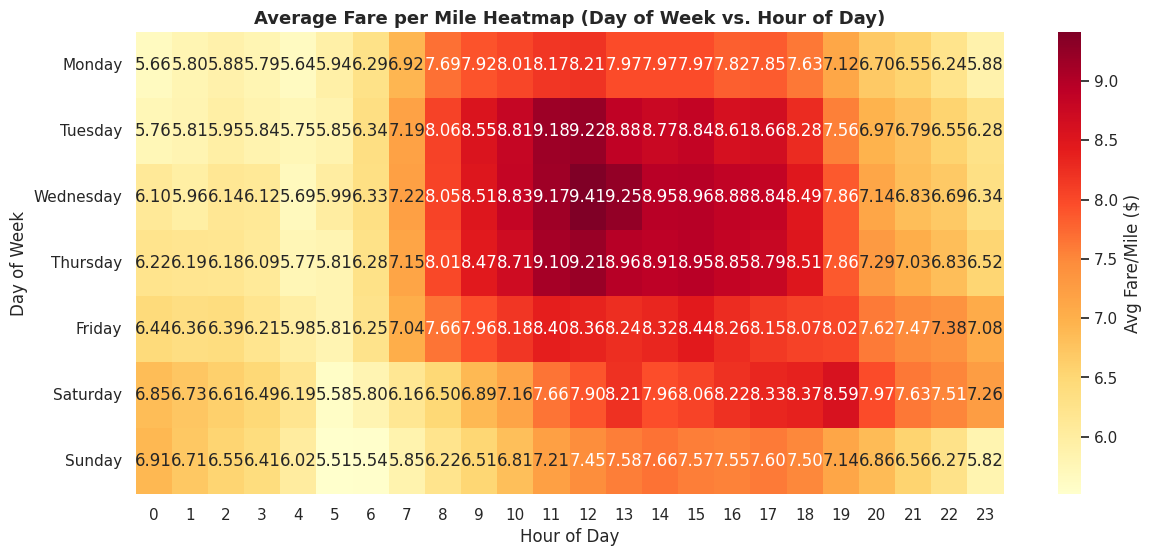

In [75]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Hourly Trend
sns.lineplot(data=hourly_fare_per_mile, x='pickup_hour', y='fare_per_mile', marker='o', color='crimson', linewidth=2.5, ax=axes[0])
axes[0].set_title('Average Fare per Mile by Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour of Day (0-23)')
axes[0].set_ylabel('Fare per Mile ($/mi)')
axes[0].set_xticks(range(0, 24))

# Plot 2: Daily Trend
sns.barplot(data=daily_fare_per_mile, x='pickup_day_name', y='fare_per_mile', palette='viridis', ax=axes[1])
axes[1].set_title('Average Fare per Mile by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Fare per Mile ($/mi)')

plt.tight_layout()
plt.show()

# Heatmap Plot (Interactive View across Hour & Day)
plt.figure(figsize=(14, 6))
sns.heatmap(pivot_fare_per_mile, cmap='YlOrRd', annot=True, fmt=".2f", cbar_kws={'label': 'Avg Fare/Mile ($)'})
plt.title('Average Fare per Mile Heatmap (Day of Week vs. Hour of Day)', fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [76]:
# Compare fare per mile for different vendors
# 1. Filter out trips with distance < 0.1 miles to avoid extreme spikes/division errors
df_vendor_fare = df[df['trip_distance'] >= 0.1].copy()

# 2. Calculate Fare per Mile
df_vendor_fare['fare_per_mile'] = df_vendor_fare['fare_amount'] / df_vendor_fare['trip_distance']

# Filter extreme fare per mile values for a clean comparative plot (e.g. <= $50/mile)
df_vendor_fare = df_vendor_fare[df_vendor_fare['fare_per_mile'] <= 50]

# 3. Map Vendor IDs to human-readable names
vendor_map = {1: 'Creative Mobile Technologies (1)', 2: 'VeriFone Inc. (2)'}
df_vendor_fare['vendor_name'] = df_vendor_fare['VendorID'].map(vendor_map)

# 4. Group by Vendor and Hour of Day
vendor_hourly_fare = df_vendor_fare.groupby(['pickup_hour', 'vendor_name'])['fare_per_mile'].mean().reset_index()

# Overall average summary per vendor
overall_vendor_fare = df_vendor_fare.groupby('vendor_name')['fare_per_mile'].agg(['mean', 'median', 'std', 'count'])
print("--- OVERALL AVERAGE FARE PER MILE BY VENDOR ---")
display(overall_vendor_fare)


--- OVERALL AVERAGE FARE PER MILE BY VENDOR ---


,mean,median,std,count
vendor_name,,,,
Creative Mobile Technologies (1),7.888961,7.153846,3.660842,473660
VeriFone Inc. (2),7.736405,7.135678,3.321896,1328510


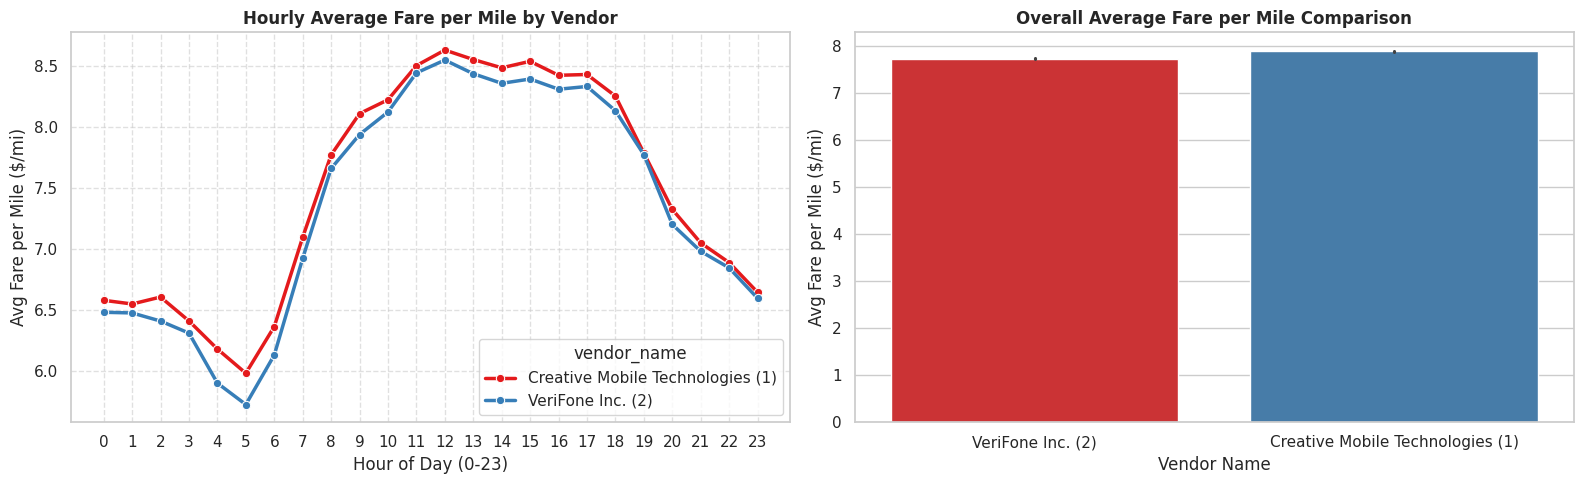

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Line plot comparing Vendors across Hours of Day
sns.lineplot(
    data=vendor_hourly_fare,
    x='pickup_hour',
    y='fare_per_mile',
    hue='vendor_name',
    marker='o',
    linewidth=2.5,
    palette='Set1',
    ax=axes[0]
)
axes[0].set_title('Hourly Average Fare per Mile by Vendor', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour of Day (0-23)')
axes[0].set_ylabel('Avg Fare per Mile ($/mi)')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Overall Comparison Barplot (FIXED)
sns.barplot(
    data=df_vendor_fare,
    x='vendor_name',
    y='fare_per_mile',
    hue='vendor_name',
    palette='Set1',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Overall Average Fare per Mile Comparison', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Vendor Name')
axes[1].set_ylabel('Avg Fare per Mile ($/mi)')

plt.tight_layout()
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [78]:
# Defining distance tiers
# 1. Filter out trips with distance < 0.1 miles to avoid division errors
df_tiered = df[df['trip_distance'] >= 0.1].copy()

# 2. Calculate Fare per Mile
df_tiered['fare_per_mile'] = df_tiered['fare_amount'] / df_tiered['trip_distance']

# Filter extreme fare per mile values for clean visualization
df_tiered = df_tiered[df_tiered['fare_per_mile'] <= 50]

# 3. Map Vendor IDs to human-readable names
vendor_map = {1: 'Creative Mobile Tech (1)', 2: 'VeriFone Inc. (2)'}
df_tiered['vendor_name'] = df_tiered['VendorID'].map(vendor_map)

# 4. Define Distance Tiers
def assign_distance_tier(dist):
    if dist <= 2.0:
        return '1. Short (<= 2 mi)'
    elif dist <= 5.0:
        return '2. Medium (2-5 mi)'
    else:
        return '3. Long (> 5 mi)'

df_tiered['distance_tier'] = df_tiered['trip_distance'].apply(assign_distance_tier)

# 5. Group by Tier and Vendor
tiered_summary = df_tiered.groupby(['distance_tier', 'vendor_name'])['fare_per_mile'].agg(
    ['mean', 'median', 'std', 'count']
).reset_index()

print("--- AVERAGE FARE PER MILE ACROSS DISTANCE TIERS BY VENDOR ---")
display(tiered_summary)


--- AVERAGE FARE PER MILE ACROSS DISTANCE TIERS BY VENDOR ---


,distance_tier,vendor_name,mean,median,std,count
0,1. Short (<= 2 mi),Creative Mobile Tech (1),9.520647,8.500000,3.861765,274391
1,1. Short (<= 2 mi),VeriFone Inc. (2),9.403436,8.552632,3.441764,722981
2,2. Medium (2-5 mi),Creative Mobile Tech (1),6.378341,6.095238,1.517060,124287
3,2. Medium (2-5 mi),VeriFone Inc. (2),6.546826,6.253165,1.571054,368329
4,3. Long (> 5 mi),Creative Mobile Tech (1),4.421870,4.268293,0.850922,74982
5,3. Long (> 5 mi),VeriFone Inc. (2),4.502526,4.312925,0.860720,237200


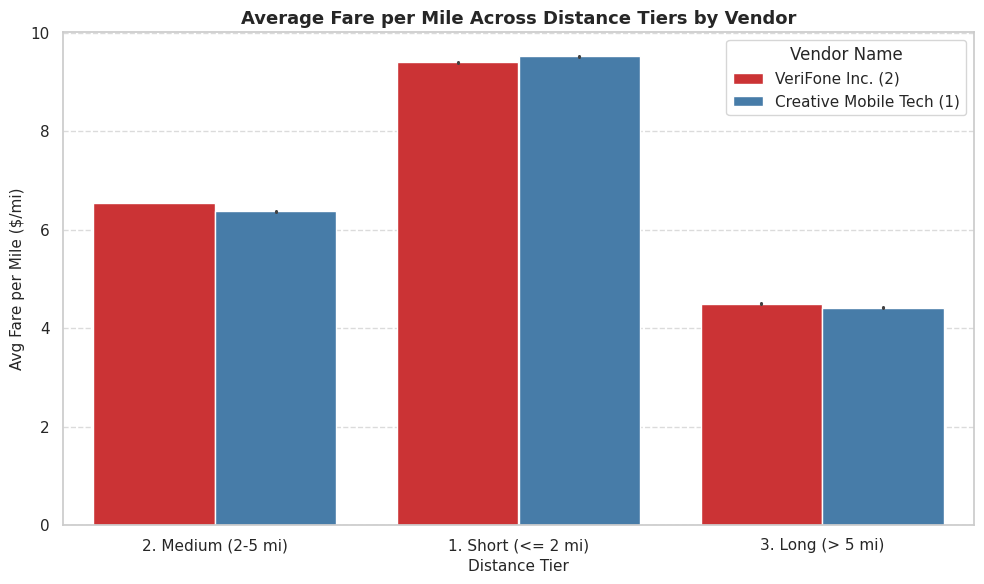

In [79]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_tiered,
    x='distance_tier',
    y='fare_per_mile',
    hue='vendor_name',
    palette='Set1'
)

plt.title('Average Fare per Mile Across Distance Tiers by Vendor', fontsize=13, fontweight='bold')
plt.xlabel('Distance Tier', fontsize=11)
plt.ylabel('Avg Fare per Mile ($/mi)', fontsize=11)
plt.legend(title='Vendor Name')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

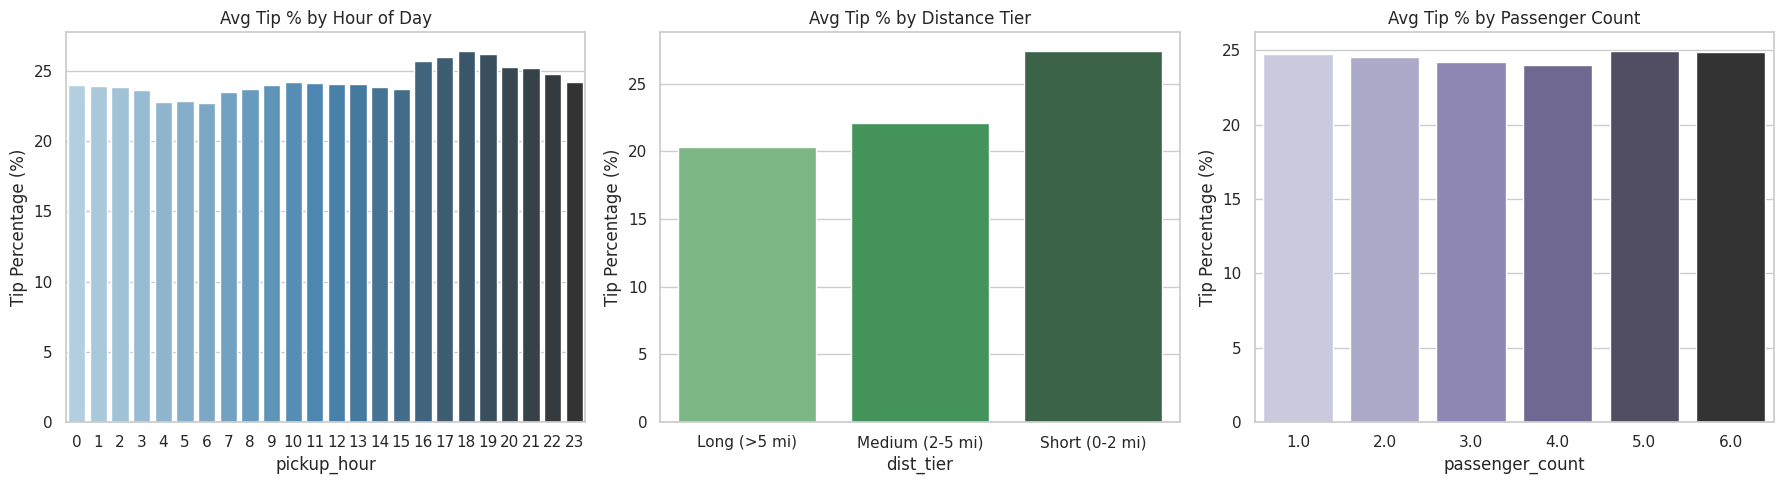

In [80]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
# Filter for Credit Card trips with valid fare amounts
cc_df = df[(df['payment_type'] == 1) & (df['fare_amount'] > 0) & (df['trip_distance'] > 0)].copy()

# Calculate Tip Percentage
cc_df['tip_pct'] = (cc_df['tip_amount'] / cc_df['fare_amount']) * 100

# Remove extreme percentage anomalies for robust statistics (e.g., tip_pct <= 100)
cc_df = cc_df[cc_df['tip_pct'] <= 100]

# --- 1. Tip % by Pickup Hour ---
hourly_tip = cc_df.groupby('pickup_hour')['tip_pct'].mean().reset_index()

# --- 2. Tip % by Distance Tier ---
def assign_dist_tier(d):
    if d <= 2: return 'Short (0-2 mi)'
    elif d <= 5: return 'Medium (2-5 mi)'
    else: return 'Long (>5 mi)'

cc_df['dist_tier'] = cc_df['trip_distance'].apply(assign_dist_tier)
tier_tip = cc_df.groupby('dist_tier')['tip_pct'].mean().reset_index()

# --- 3. Tip % by Passenger Count ---
pax_tip = cc_df.groupby('passenger_count')['tip_pct'].mean().reset_index()

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Hourly
sns.barplot(data=hourly_tip, x='pickup_hour', y='tip_pct', hue='pickup_hour', palette='Blues_d', legend=False, ax=axes[0])
axes[0].set_title('Avg Tip % by Hour of Day')
axes[0].set_ylabel('Tip Percentage (%)')

# Plot 2: Distance Tier
sns.barplot(data=tier_tip, x='dist_tier', y='tip_pct', hue='dist_tier', palette='Greens_d', legend=False, ax=axes[1])
axes[1].set_title('Avg Tip % by Distance Tier')
axes[1].set_ylabel('Tip Percentage (%)')

# Plot 3: Passenger Count
sns.barplot(data=pax_tip, x='passenger_count', y='tip_pct', hue='passenger_count', palette='Purples_d', legend=False, ax=axes[2])
axes[2].set_title('Avg Tip % by Passenger Count')
axes[2].set_ylabel('Tip Percentage (%)')

plt.tight_layout()
plt.show()


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [81]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
# 1. Filter for Credit Card trips with positive fares
cc_trips = df[(df['payment_type'] == 1) & (df['fare_amount'] > 0) & (df['trip_distance'] > 0)].copy()

# 2. Calculate Tip Percentage
cc_trips['tip_pct'] = (cc_trips['tip_amount'] / cc_trips['fare_amount']) * 100

# 3. Define Cohorts
low_tips = cc_trips[cc_trips['tip_pct'] < 10].copy()
high_tips = cc_trips[(cc_trips['tip_pct'] > 25) & (cc_trips['tip_pct'] <= 100)].copy()

low_tips['tip_cohort'] = 'Low Tip (<10%)'
high_tips['tip_cohort'] = 'High Tip (>25%)'

# Combine cohorts into a single comparison DataFrame
cohort_df = pd.concat([low_tips, high_tips])

# Calculate average speed (mph) for congestion analysis
cohort_df['speed_mph'] = cohort_df['trip_distance'] / (cohort_df['trip_duration_min'] / 60.0)

# 4. Compute Statistical Summary
comparison_metrics = cohort_df.groupby('tip_cohort').agg(
    Avg_Distance=('trip_distance', 'mean'),
    Avg_Fare=('fare_amount', 'mean'),
    Avg_Duration_Min=('trip_duration_min', 'mean'),
    Avg_Speed_MPH=('speed_mph', 'mean'),
    Avg_Tolls=('tolls_amount', 'mean'),
    Avg_Airport_Fee=('Airport_fee', 'mean'),
    Avg_Congestion_Surcharge=('congestion_surcharge', 'mean'),
    Trip_Count=('fare_amount', 'count')
).reset_index()

print("--- COHORT STATISTICAL COMPARISON ---")
display(comparison_metrics)


--- COHORT STATISTICAL COMPARISON ---


,tip_cohort,Avg_Distance,Avg_Fare,Avg_Duration_Min,Avg_Speed_MPH,Avg_Tolls,Avg_Airport_Fee,Avg_Congestion_Surcharge,Trip_Count
0,High Tip (>25%),2.301844,14.419267,12.742381,10.594211,0.456808,0.085633,2.435273,811521
1,Low Tip (<10%),4.862158,25.734304,24.951748,13.255879,0.851592,0.182474,2.093017,142437


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

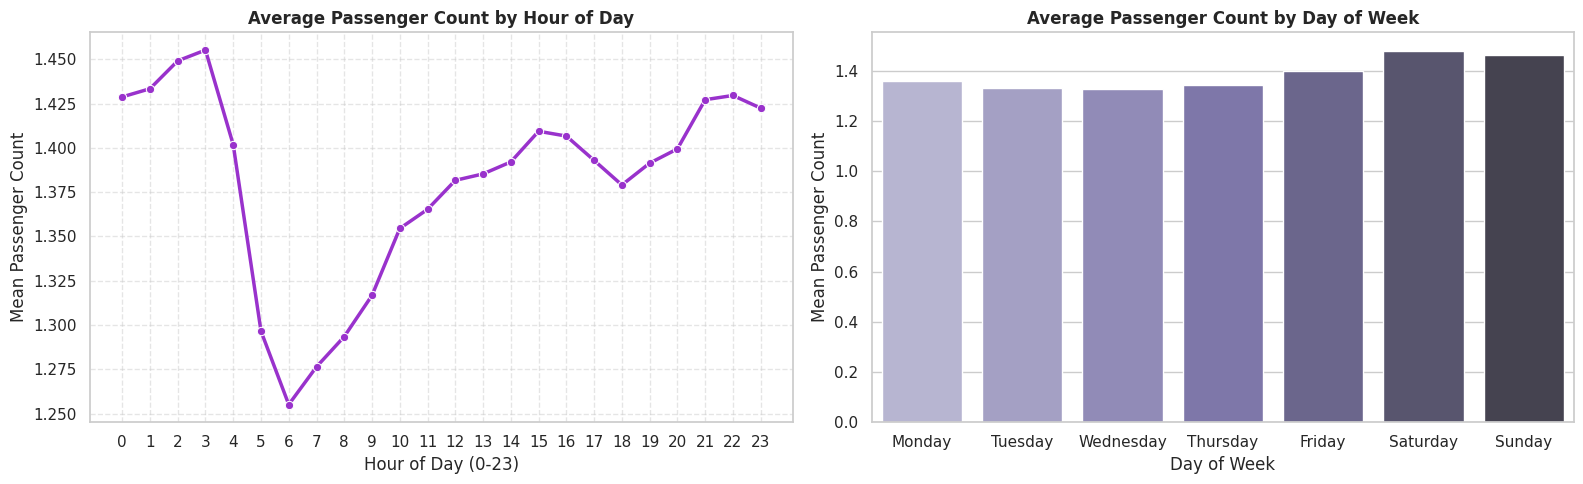

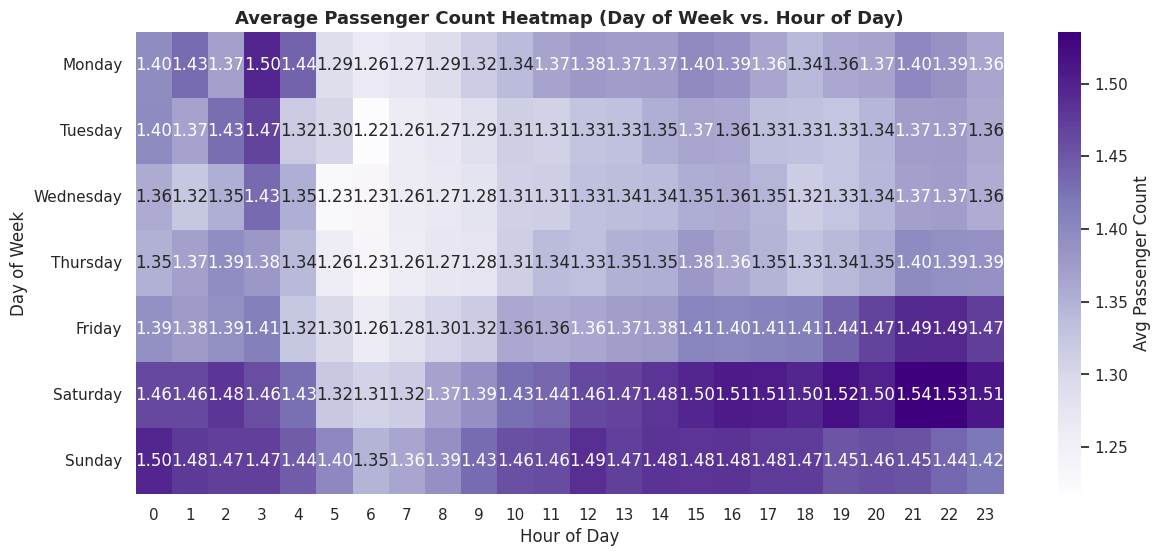

In [82]:
# See how passenger count varies across hours and days
# Ensure days of week are properly ordered
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 1. Average Passenger Count by Hour of Day
hourly_pax = df.groupby('pickup_hour')['passenger_count'].mean().reset_index()

# 2. Average Passenger Count by Day of Week
daily_pax = df.groupby('pickup_day_name')['passenger_count'].mean().reindex(days_order).reset_index()

# 3. Pivot Table for Heatmap (Hour vs Day of Week)
pivot_pax = df.pivot_table(
    index='pickup_day_name',
    columns='pickup_hour',
    values='passenger_count',
    aggfunc='mean'
).reindex(days_order)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Average Passenger Count by Hour
sns.lineplot(
    data=hourly_pax,
    x='pickup_hour',
    y='passenger_count',
    marker='o',
    color='darkorchid',
    linewidth=2.5,
    ax=axes[0]
)
axes[0].set_title('Average Passenger Count by Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour of Day (0-23)')
axes[0].set_ylabel('Mean Passenger Count')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Average Passenger Count by Day of Week
sns.barplot(
    data=daily_pax,
    x='pickup_day_name',
    y='passenger_count',
    hue='pickup_day_name',
    palette='Purples_d',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Average Passenger Count by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Mean Passenger Count')

plt.tight_layout()
plt.show()

# Plot 3: Heatmap (Hour vs. Day of Week)
plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot_pax,
    cmap='Purples',
    annot=True,
    fmt=".2f",
    cbar_kws={'label': 'Avg Passenger Count'}
)
plt.title('Average Passenger Count Heatmap (Day of Week vs. Hour of Day)', fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

--- TOP 5 ZONES WITH HIGHEST AVERAGE PASSENGER COUNT ---


,LocationID,zone,borough,avg_passenger_count
194,195,Red Hook,Brooklyn,1.800995
11,12,Battery Park,Manhattan,1.743902
0,1,Newark Airport,EWR,1.605634
65,66,DUMBO/Vinegar Hill,Brooklyn,1.584582
260,261,World Trade Center,Manhattan,1.545805



--- TOP 5 ZONES WITH LOWEST AVERAGE PASSENGER COUNT ---


,LocationID,zone,borough,avg_passenger_count
22,23,Bloomfield/Emerson Hill,Staten Island,1.0
31,32,Bronxdale,Bronx,1.0
77,78,East Tremont,Bronx,1.0
50,51,Co-Op City,Bronx,1.0
125,126,Hunts Point,Bronx,1.0


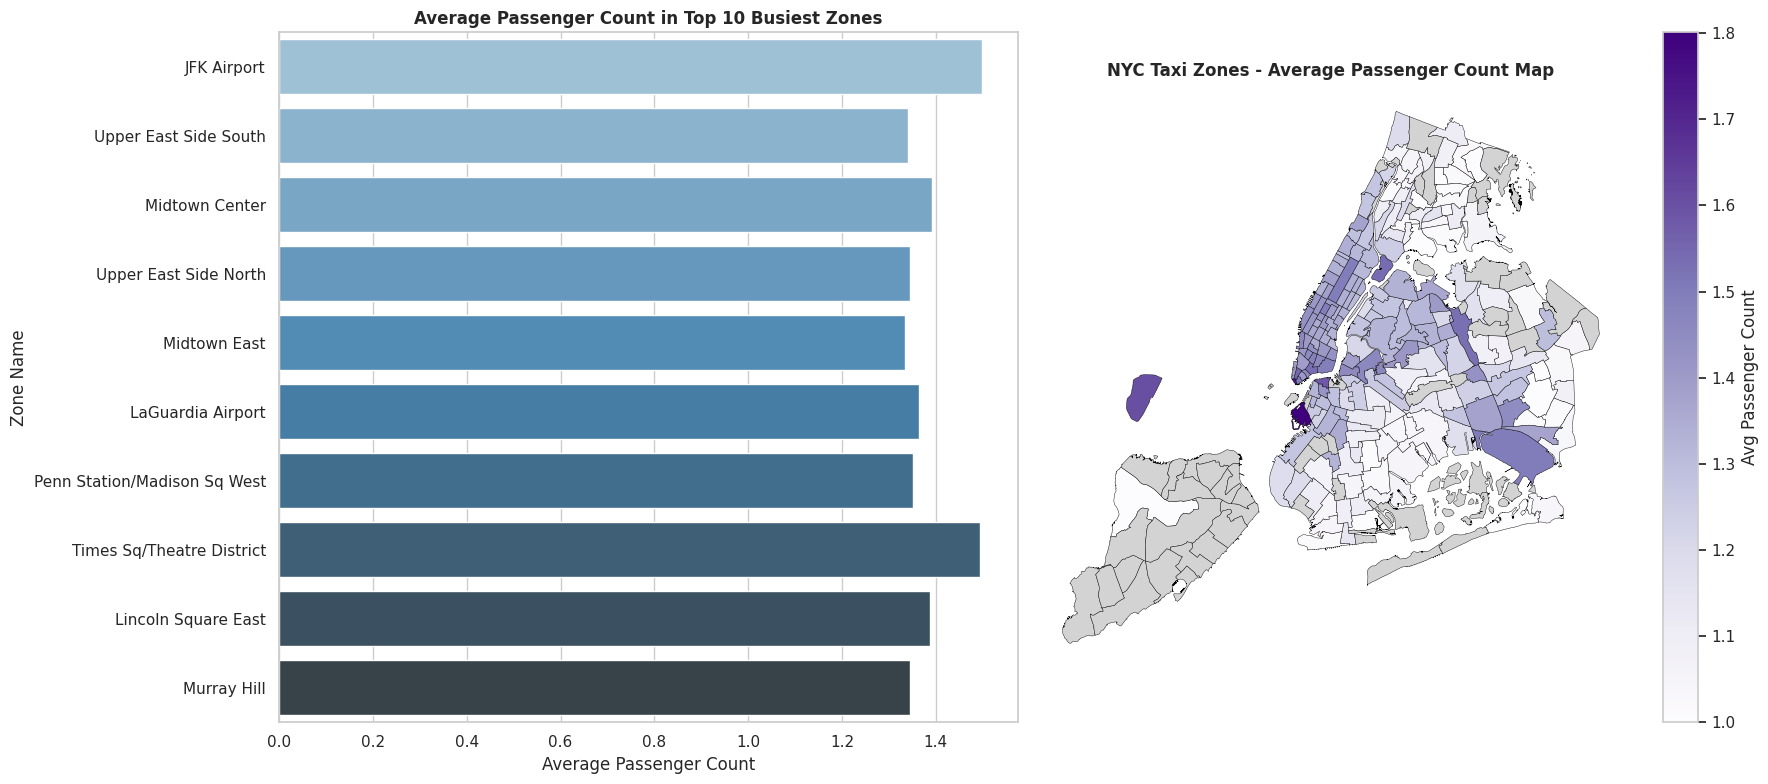

In [83]:
# How does passenger count vary across zones
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
# 1. Calculate Average Passenger Count per Pickup Zone
zone_pax = df.groupby('PULocationID')['passenger_count'].agg(['mean', 'count']).reset_index()
zone_pax.columns = ['LocationID', 'avg_passenger_count', 'trip_count']

# Filter out zones with very low trip counts (< 30 trips) to avoid single-trip outliers
zone_pax_valid = zone_pax[zone_pax['trip_count'] >= 30]

# 2. Merge with 'zones' GeoDataFrame to attach Zone Names & Geometry
zones_pax_geo = zones.merge(zone_pax_valid, on='LocationID', how='left')

# Print Top & Bottom 5 Zones by Average Passenger Count
print("--- TOP 5 ZONES WITH HIGHEST AVERAGE PASSENGER COUNT ---")
display(zones_pax_geo.sort_values(by='avg_passenger_count', ascending=False)[['LocationID', 'zone', 'borough', 'avg_passenger_count']].head(5))

print("\n--- TOP 5 ZONES WITH LOWEST AVERAGE PASSENGER COUNT ---")
display(zones_pax_geo.sort_values(by='avg_passenger_count', ascending=True)[['LocationID', 'zone', 'borough', 'avg_passenger_count']].head(5))

# ==============================================================================
# VISUALIZATIONS
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Top 10 Busiest Zones Average Passenger Count Barplot
top_10_zones = zones_pax_geo.sort_values(by='trip_count', ascending=False).head(10)

sns.barplot(
    data=top_10_zones,
    x='avg_passenger_count',
    y='zone',
    hue='zone',
    palette='Blues_d',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Average Passenger Count in Top 10 Busiest Zones', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Passenger Count')
axes[0].set_ylabel('Zone Name')

# Plot 2: Choropleth Map showing Average Passenger Count by Zone
zones_pax_geo.plot(
    column='avg_passenger_count',
    ax=axes[1],
    legend=True,
    cmap='Purples',
    edgecolor='black',
    linewidth=0.3,
    missing_kwds={'color': 'lightgrey', 'label': 'Insufficient Data'},
    legend_kwds={'label': 'Avg Passenger Count', 'orientation': 'vertical'}
)
axes[1].set_title('NYC Taxi Zones - Average Passenger Count Map', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [84]:
# How often is each surcharge applied?
# Total number of valid trips
total_trips = len(df)

# Dictionary of surcharges present in the dataset
surcharges = {
    'Congestion Surcharge ($2.50)': (df['congestion_surcharge'] > 0).sum(),
    'MTA Tax ($0.50)': (df['mta_tax'] > 0).sum(),
    'Improvement Surcharge ($1.00)': (df['improvement_surcharge'] > 0).sum(),
    'Airport Fee': (df['Airport_fee'] > 0).sum(),
    'Tolls Paid': (df['tolls_amount'] > 0).sum()
}

# Create summary DataFrame
surcharge_freq_df = pd.DataFrame(list(surcharges.items()), columns=['Surcharge Type', 'Applied Trip Count'])
surcharge_freq_df['Frequency (%)'] = (surcharge_freq_df['Applied Trip Count'] / total_trips) * 100
surcharge_freq_df['Frequency (%)'] = surcharge_freq_df['Frequency (%)'].round(2)

# Display results sorted by frequency
surcharge_freq_df = surcharge_freq_df.sort_values(by='Frequency (%)', ascending=False).reset_index(drop=True)
display(surcharge_freq_df)


,Surcharge Type,Applied Trip Count,Frequency (%)
0,Improvement Surcharge ($1.00),1830708,99.97
1,MTA Tax ($0.50),1814351,99.08
2,Congestion Surcharge ($2.50),1690254,92.30
3,Airport Fee,161167,8.80
4,Tolls Paid,148728,8.12


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

Mentioned in report

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

Mentioned in report

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

Mentioned in report